# BAB in Crypto

## Motivation:
Frazzini and Pedersen (2014) construct Betting Against Beta (BAB) factor, which goes long low-beta assets and shorts high-beta assets. They show that this factor earns significant and positive risk-adjusted returns. Their claim is that this arises from leverage constraints: if investors (institutional or retail) cannot lever up the Sharpe-optimal portfolio to their desired level of risk then they will instead buy high-beta assets, such as leveraged ETFs. They then construct the BAB factor as a way for an unconstrained arbitrageur to take advantage of this phenomenon.

I hope to answer two questions in this project:
1. Does the BAB effect exist in cryptocurrency markets? One advantage in cryptocurrency markets is that leverage constraints can be observed directly through the perpetual funding rate, rather than proxied as the original authors do.
2. If the BAB factor delivers positive returns in cryptocurrency markets is there an implementable trading strategy that can be used to capture these returns?

In [32]:
# Setup
import io
import os
import zipfile
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
import statsmodels.api as sm

import pandas as pd
import numpy as np
import requests

ARCHIVE = 'https://data.binance.vision/data'
S3 = 'https://s3-ap-northeast-1.amazonaws.com/data.binance.vision'
NS = '{http://s3.amazonaws.com/doc/2006-03-01/}'

START, END = '2017-08', '2026-08'

DATA = 'data'
os.makedirs(DATA, exist_ok=True)

ANALYSIS = 'analysis'
os.makedirs(ANALYSIS, exist_ok=True)

KLINE_COLS = ['open_time', 'open', 'high', 'low', 'close', 'volume',
              'close_time', 'quote_volume', 'trades', 'taker_base',
              'taker_quote', 'ignore']
FUNDING_COLS = ['calc_time', 'funding_interval_hours', 'last_funding_rate']

# kind -> (archive path, timestamp column, columns)
KINDS = {
    'spot':    ('spot/monthly/klines',            'open_time', KLINE_COLS),
    'futures': ('futures/um/monthly/klines',      'open_time', KLINE_COLS),
    'funding': ('futures/um/monthly/fundingRate', 'calc_time', FUNDING_COLS),
}

# Data

Data comes from Binance's public archive at `data.binance.vision`.

Importantly, the archive **keeps delisted symbols**. LUNA, FTT and SRM are all still in it. This study is short high-beta coins, and a fair amount of high-beta coins end up going to zero. If our data covered only what trades today we would introducing significant survivorship bias.

Take every USDT symbol in the archive, keep every row, and apply no filters
at this stage.

### Every symbol in the archive

`exchangeInfo` only lists instruments that currently exist, so it can't be used
here. The S3 listing includes everything that ever traded.

In [33]:
def list_symbols(kind):
    """Every symbol in the archive, including delisted ones."""
    prefix = f'data/{KINDS[kind][0]}/'
    out, token = [], None
    while True:
        params = {'delimiter': '/', 'prefix': prefix, 'list-type': '2'}
        if token:
            params['continuation-token'] = token
        root = ET.fromstring(requests.get(S3, params=params, timeout=60).text)
        out += [c.find(NS + 'Prefix').text.rstrip('/').split('/')[-1]
                for c in root.findall(NS + 'CommonPrefixes')]
        nxt = root.find(NS + 'NextContinuationToken')
        if nxt is None:
            return sorted(out)
        token = nxt.text


spot_symbols = [s for s in list_symbols('spot') if s.endswith('USDT')]
perp_symbols = [s for s in list_symbols('funding') if s.endswith('USDT')]

print(f'{len(spot_symbols)} spot, {len(perp_symbols)} perp symbols')

735 spot, 865 perp symbols


### Downloading

`1d` in the URL is the interval — daily bars, ~2 KB per symbol-month. One file
per symbol per month, so a 404 just means the symbol didn't trade that month.

Two file-format quirks, both handled in `get_month`, and both of which corrupt
the data silently rather than raising:

1. timestamps are **milliseconds before 2025-01 and microseconds after**, and at
   least one file (`KLAYUSDT` 2024-10) contains *both* — so the unit is detected
   per row, not per file;
2. futures files carry a header row, spot files do not.

One pickle per symbol, so an interrupted run resumes cleanly. Roughly 40 minutes
per dataset at 16 workers; re-running skips anything already cached.

In [34]:
def get_month(url, cols, tcol):
    """One monthly zip -> DataFrame, or None if that month doesn't exist."""
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        return None
    z = zipfile.ZipFile(io.BytesIO(r.content))
    raw = z.read(z.namelist()[0]).decode()
    if not raw.strip():
        return None

    first = raw.split('\n', 1)[0].split(',')[0]
    has_header = not first.replace('.', '').replace('-', '').isdigit()
    df = pd.read_csv(io.StringIO(raw), header=0 if has_header else None)
    if not has_header:
        df.columns = cols[:df.shape[1]]

    t = df[tcol].astype('int64')
    t = t.where(t < 1e14, t // 1000)          # microseconds -> milliseconds
    df[tcol] = pd.to_datetime(t, unit='ms')
    return df.set_index(tcol)


def get_symbol(symbol, kind):
    path, tcol, cols = KINDS[kind]
    parts = []
    for ts in pd.date_range(f'{START}-01', f'{END}-01', freq='MS'):
        ym = ts.strftime('%Y-%m')
        if kind == 'funding':
            url = f'{ARCHIVE}/{path}/{symbol}/{symbol}-fundingRate-{ym}.zip'
        else:
            url = f'{ARCHIVE}/{path}/{symbol}/1d/{symbol}-1d-{ym}.zip'
        df = get_month(url, cols, tcol)
        if df is not None:
            parts.append(df)
    return pd.concat(parts).sort_index() if parts else None


def download(symbols, kind, workers=16):
    out_dir = os.path.join(DATA, kind)
    os.makedirs(out_dir, exist_ok=True)
    todo = [s for s in symbols
            if not os.path.exists(os.path.join(out_dir, f'{s}.pkl'))]
    print(f'{kind}: {len(todo)} to fetch, {len(symbols) - len(todo)} cached')

    def work(sym):
        try:
            return sym, get_symbol(sym, kind)
        except Exception:
            return sym, None

    with ThreadPoolExecutor(workers) as ex:
        for i, f in enumerate(as_completed([ex.submit(work, s) for s in todo]), 1):
            sym, df = f.result()
            if df is not None and len(df):
                df.to_pickle(os.path.join(out_dir, f'{sym}.pkl'))
            if i % 50 == 0:
                print(f'  {i}/{len(todo)}', flush=True)
    print(f'{kind}: done')

In [35]:
download(spot_symbols, 'spot')
download(perp_symbols, 'futures')
download(perp_symbols, 'funding')

spot: 1 to fetch, 734 cached
spot: done
futures: 1 to fetch, 864 cached
futures: done
funding: 0 to fetch, 865 cached
funding: done


### Panels

Four cleaning rules, applied identically to spot and perps. Each is one line,
and each has a specific failure behind it:

| Rule | Why |
|---|---|
| drop `UP`/`DOWN`/`BULL`/`BEAR` tickers | leveraged products, not coins — 52 of them, and `AAVEDOWNUSDT` has a +1,472,230% redenomination day |
| drop 10 tickers with price discontinuities | token redenominations (`SUNUSDT` 1:1000, `BNXUSDT` 1:100) plus one reused ticker (`LUNAUSDT` — Terra Classic then Terra 2.0, a naive +17,739,900% return). Binance klines are unadjusted, like raw stock prices before split adjustment. Ten coins out of 670; cheaper to drop than to adjust |
| require a price on both days | otherwise a trading halt fabricates a multi-day return on the day it resumes |
| perps only: require volume > 0 | a halted perp keeps publishing bars at a frozen mark. `FTTUSDT` sat at 1.5900 with zero trades for a year, which reads as zero volatility — a naive beta then ranks it lowest and BAB goes long it |

Funding is **summed** to daily rather than averaged, because it is a flow and the
interval is not constant: Binance shortens it from 8h to 2h under stress, so
`FTTUSDT` went from 3 payments a day to 12 during the FTX collapse.

In [36]:
LEVERAGED = ('UPUSDT', 'DOWNUSDT', 'BULLUSDT', 'BEARUSDT')

# price discontinuities: redenominations, plus one reused ticker (LUNAUSDT)
DISCONTINUOUS = ['BNXUSDT', 'BTCSTUSDT', 'COCOSUSDT', 'DREPUSDT', 'LUNAUSDT',
                 'QUICKUSDT', 'STRAXUSDT', 'SUNUSDT', 'VENUSDT', 'VIDTUSDT']

# Not crypto assets. Dropping these is a definition of the asset class, not a
# survivorship filter -- it removes instruments that never belonged, rather than
# coins that failed. It matters more than it looks: a stablecoin has ~0 beta and
# ~2% annualised volatility, so BAB puts it at the very top of the long leg and
# ends up levered long the dollar. Before this screen the entire bottom of the
# beta ranking was stablecoins, fiat pairs and tokenised gold.
STABLE_FIAT = ['USDCUSDT', 'TUSDUSDT', 'USDPUSDT', 'BUSDUSDT', 'FDUSDUSDT',
               'PAXUSDT', 'USDSUSDT', 'USDSBUSDT', 'SUSDUSDT', 'USDEUSDT',
               'USD1USDT', 'XUSDUSDT', 'RLUSDUSDT', 'BFUSDUSDT', 'UUSDT',
               'KGSTUSDT', 'DAIUSDT', 'EURUSDT', 'EURIUSDT', 'AEURUSDT', 'GBPUSDT',
               'AUDUSDT', 'BKRWUSDT']
COMMODITY = ['PAXGUSDT', 'XAUTUSDT', 'XAUUSDT', 'XAGUSDT']

# Wrapped and staked duplicates of assets already in the universe. Their daily
# correlation to the underlying is 0.998-0.999, so they double-count BTC and ETH
# in the cross-section. Excluded by CoinDesk and CoinMarketCap on the same
# grounds ("must not be wrapped, pegged, or staked assets").
WRAPPED = ['WBTCUSDT', 'BETHUSDT', 'WBETHUSDT']

# SPOT: Binance began listing tokenised equities and ETFs in June 2026, all with
# a B suffix. Every *BUSDT symbol from that date is a stock or ETF; every one
# before it is genuine crypto (BNB, SHIB, ARB, CKB, DGB), so the listing date
# separates them cleanly.
#
# PERP: the same instruments trade under plain tickers (NVDAUSDT, SPYUSDT,
# COPPERUSDT, even OPENAIUSDT), so the suffix rule doesn't work and listing date
# alone doesn't either -- real coins list constantly. They are separated instead
# by being both new and far less volatile than crypto: BTC runs ~67% annualised,
# and every one of the ~76 tokenised perps is under 60%.
TOKENISED_EQUITY_FROM = '2026-06-01'

TOKENISED_PERP_FROM = '2026-01-01'
TOKENISED_PERP_MAXVOL = 0.60

DROP_TICKERS = DISCONTINUOUS + STABLE_FIAT + COMMODITY + WRAPPED


def build_panel(kind, field, how='last'):
    out_dir = os.path.join(DATA, kind)
    series = {}
    for fn in sorted(os.listdir(out_dir)):
        df = pd.read_pickle(os.path.join(out_dir, fn))
        if field not in df.columns:
            continue
        s = pd.to_numeric(df[field], errors='coerce')
        s = s[~s.index.duplicated(keep='last')]
        series[fn[:-4]] = s.resample('D').sum(min_count=1) if how == 'sum' else s
    return pd.DataFrame(series).sort_index()


def load_clean(kind):
    """Daily returns and USDT volume for one instrument type."""
    px = build_panel(kind, 'close')
    vol = build_panel(kind, 'quote_volume')

    if kind == 'futures':
        px = px.where(vol > 0)                  # frozen halted contracts

    first = px.apply(lambda s: s.first_valid_index())
    annvol = px.pct_change(fill_method=None).std() * np.sqrt(365)

    if kind == 'futures':
        # plain tickers, so identified by being new AND far less volatile
        # than crypto (BTC ~67%); every tokenised perp is under 60%
        tokenised = [c for c in px.columns
                     if pd.notna(first[c])
                     and first[c] >= pd.Timestamp(TOKENISED_PERP_FROM)
                     and annvol[c] < TOKENISED_PERP_MAXVOL]
    else:
        # spot tokenised equities all carry a B suffix and listed June 2026
        tokenised = [c for c in px.columns
                     if c.endswith('BUSDT') and pd.notna(first[c])
                     and first[c] >= pd.Timestamp(TOKENISED_EQUITY_FROM)]

    drop = [c for c in px.columns
            if any(c.endswith(k) for k in LEVERAGED)
            or c in DROP_TICKERS or c in tokenised]
    px = px.drop(columns=drop)
    vol = vol.drop(columns=drop, errors='ignore')

    ret = px.pct_change(fill_method=None).where(px.notna() & px.shift().notna())
    return ret, vol.reindex_like(px).where(px.notna()), len(drop)


ret, volume, n_drop = load_clean('spot')
ret_perp, volume_perp, n_drop_p = load_clean('futures')

funding = (build_panel('funding', 'last_funding_rate', how='sum')
           .reindex_like(ret_perp).where(ret_perp.notna()))

# Start the sample once the cross-section is large enough to define a market.
# Before this the panel is a handful of coins -- in early 2018 it is BTC and ETH
# alone -- and a volume-weighted index of two assets is not a market index.
# Applied here so every saved panel shares one start date.
MIN_COINS = 20
nCoins = ret.notna().sum(axis=1)
SAMPLE_START = nCoins[nCoins >= MIN_COINS].index.min()
ret, volume = ret.loc[SAMPLE_START:], volume.loc[SAMPLE_START:]
ret_perp, volume_perp, funding = (ret_perp.loc[SAMPLE_START:],
                                  volume_perp.loc[SAMPLE_START:],
                                  funding.loc[SAMPLE_START:])
print(f'sample starts {SAMPLE_START.date()} ({MIN_COINS}+ coins)')

for name, obj in [('ret', ret), ('volume', volume), ('ret_perp', ret_perp),
                  ('volume_perp', volume_perp), ('funding', funding)]:
    obj.to_pickle(os.path.join(DATA, f'{name}.pkl'))

print(f'spot     {str(ret.shape):14s} {ret.dropna(how="all").index.min().date()} -> '
      f'{ret.dropna(how="all").index.max().date()}  ({n_drop} tickers dropped)')
print(f'perp     {str(ret_perp.shape):14s} {ret_perp.dropna(how="all").index.min().date()} -> '
      f'{ret_perp.dropna(how="all").index.max().date()}  ({n_drop_p} dropped)')
print(f'funding  {str(funding.shape):14s} columns match perps: '
      f'{list(funding.columns) == list(ret_perp.columns)}')

sample starts 2019-01-17 (20+ coins)
spot     (2780, 576)    2019-01-17 -> 2026-07-31  (158 tickers dropped)
perp     (2435, 768)    2020-01-02 -> 2026-08-31  (96 dropped)
funding  (2435, 768)    columns match perps: True


In [37]:
# sanity checks
print(f'max daily return   spot {ret.max().max():>8.1%}   perp {ret_perp.max().max():>8.1%}')
print(f'min daily return   spot {ret.min().min():>8.1%}   perp {ret_perp.min().min():>8.1%}')

last = ret.apply(lambda s: s.last_valid_index())
print(f'coins that stop trading before the panel ends: '
      f'{int((last < ret.index.max() - pd.Timedelta("30D")).sum())} of {ret.shape[1]}')

runs = {c: (lambda s: s.groupby((s.diff() != 0).cumsum()).size().max())(ret_perp[c].dropna())
        for c in ret_perp.columns if ret_perp[c].notna().sum() > 10}
print(f'longest run of identical perp returns: {max(runs.values())} days')

print()
print('annualised funding on a long perp, biggest payers:')
print((-funding.mean() * 365).dropna().sort_values().head(5)
      .map(lambda x: f'{x:.1%}').to_string())

max daily return   spot   468.3%   perp   531.7%
min daily return   spot   -83.9%   perp   -95.7%
coins that stop trading before the panel ends: 575 of 576
longest run of identical perp returns: 3 days

annualised funding on a long perp, biggest payers:
DOTECOUSDT         -156.1%
牛来USDT              -88.3%
BTWUSDT             -87.7%
BROCCOLIF3BUSDT     -79.2%
42USDT              -64.6%


# Motivation

Two facts motivate the rest of the analysis.

**The security market line is too flat.** CAPM says expected return should rise
one-for-one with beta. Sorting crypto into beta quintiles, it doesn't — the
realised line is flat to slightly downward-sloping, and CAPM alpha falls from
about +16% a year in the low-beta quintiles to roughly zero in the highest. That
is the Black–Jensen–Scholes observation Frazzini and Pedersen build on, and it is
what a BAB factor is designed to harvest.

**Leverage is expensive, and BAB earns most when it is most expensive.** In
equities FP have to proxy the funding constraint with the TED spread. In crypto
the price of leverage is directly observable: the perpetual funding rate is what
levered longs actually pay, quoted every eight hours per coin.

The cross-sectional version of the story doesn't show up — median funding is
about 10% annualised in *every* beta quintile, so leverage demand isn't
concentrated in high-beta coins the way the simplest reading of FP would suggest.
The time-series version does: sorting days by the aggregate funding rate a month
earlier, BAB's Sharpe rises monotonically from roughly zero when leverage is
cheap to about 1.4 when it is expensive.

*Note on ordering: these figures read `betaShrunk.pkl` and `retBAB.pkl`, which
are produced further down. On a fresh kernel, run the sections below first, then
come back to these two cells.*

saved results\security_market_line.png and logged to results\RESULTS.md
saved results\beta_quintiles.csv and logged to results\RESULTS.md


,beta,ann_ret,sharpe,alpha
Q1,0.724,0.296,0.524,0.159
Q2,1.050,0.374,0.473,0.191
Q3,1.114,0.349,0.413,0.155
Q4,1.183,0.299,0.338,0.093
Q5,1.242,0.193,0.205,-0.007


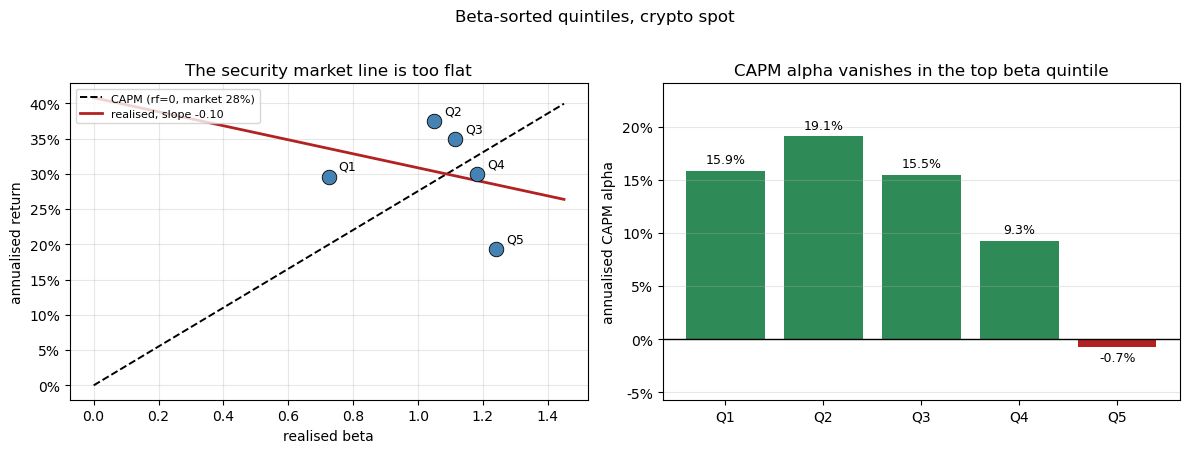

In [10]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import results as R

beta = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))
ret  = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))
mkt  = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))
fund = pd.read_pickle(os.path.join(DATA, 'funding.pkl'))
bab  = pd.read_pickle(os.path.join(DATA, 'retBAB.pkl'))

QS = [(0, .2), (.2, .4), (.4, .6), (.6, .8), (.8, 1.01)]

# --- beta-quintile portfolios: realised beta, return and CAPM alpha
q = beta.rank(axis=1, pct=True)
rows = {}
for i, (lo, hi) in enumerate(QS):
    m = ((q > lo) & (q <= hi)).astype(float)
    m = m.divide(m.sum(axis=1), axis=0)
    r = (m.shift() * ret).sum(axis=1, min_count=1)
    d = pd.concat([r.rename('y'), mkt.rename('m')], axis=1).dropna()
    f = sm.OLS(d['y'], sm.add_constant(d[['m']])).fit()
    rows[f'Q{i+1}'] = {'beta': f.params['m'], 'ann_ret': r.mean() * 365,
                       'sharpe': r.mean() / r.std() * np.sqrt(365),
                       'alpha': f.params['const'] * 365}
sml = pd.DataFrame(rows).T

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
pct = lambda v, p: f'{v:.0%}'

b, y = sml['beta'].values, sml['ann_ret'].values
xs = np.linspace(0, 1.45, 10)
ax[0].plot(xs, xs * mkt.mean() * 365, 'k--', lw=1.4,
           label=f'CAPM (rf=0, market {mkt.mean()*365:.0%})')
slope = np.polyfit(b, y, 1)
ax[0].plot(xs, np.polyval(slope, xs), color='firebrick', lw=2,
           label=f'realised, slope {slope[0]:.2f}')
ax[0].scatter(b, y, s=110, zorder=3, color='steelblue', edgecolor='k', linewidth=.6)
for lab, bi, yi in zip(sml.index, b, y):
    ax[0].annotate(lab, (bi, yi), textcoords='offset points', xytext=(7, 5), fontsize=9)
ax[0].set_xlabel('realised beta')
ax[0].set_ylabel('annualised return')
ax[0].yaxis.set_major_formatter(pct)
ax[0].set_title('The security market line is too flat')
ax[0].legend(fontsize=8, loc='upper left')
ax[0].grid(alpha=.3)

ax[1].bar(sml.index, sml['alpha'],
          color=['seagreen' if v > 0 else 'firebrick' for v in sml['alpha']])
ax[1].axhline(0, color='k', lw=1)
ax[1].set_ylabel('annualised CAPM alpha')
ax[1].yaxis.set_major_formatter(pct)
ax[1].set_ylim(sml['alpha'].min() - .05, sml['alpha'].max() + .05)
ax[1].set_title('CAPM alpha vanishes in the top beta quintile')
ax[1].grid(alpha=.3, axis='y')
for i, v in enumerate(sml['alpha']):
    ax[1].annotate(f'{v:.1%}', (i, v), ha='center', fontsize=9,
                   va='bottom' if v > 0 else 'top',
                   xytext=(0, 3 if v > 0 else -3), textcoords='offset points')

fig.suptitle('Beta-sorted quintiles, crypto spot', y=1.02)
fig.tight_layout()

R.figure(fig, 'security_market_line',
         f'Realised SML slope is {slope[0]:.2f} against a CAPM prediction of '
         f'{mkt.mean()*365:.2f}. CAPM alpha falls from {sml["alpha"].iloc[0]:.1%} in Q1 to '
         f'{sml["alpha"].iloc[-1]:.1%} in Q5, and Sharpe declines monotonically '
         f'({sml["sharpe"].iloc[0]:.2f} to {sml["sharpe"].iloc[-1]:.2f}). '
         'This is the flat-SML fact BAB is built to exploit.')
R.table(sml, 'beta_quintiles', 'Beta-sorted quintile portfolios, equal weighted, rebalanced daily.')
sml.round(3)

### Testing the slope: Fama-MacBeth

The quintile plot above is the Black, Jensen & Scholes (1972) presentation --
sort on pre-formation beta, then plot each portfolio's mean return against its
post-formation beta. It is the standard picture, and the one Frazzini and
Pedersen show, but fitting a line through five points is a weak test.

Fama and MacBeth (1973) is the standard *test*. Each day, run a cross-sectional
regression of returns on the previous day's beta; the SML slope is the
time-series mean of those daily slopes, and its standard error comes from their
variation over time. Using the lagged beta makes it a genuine prediction rather
than a contemporaneous fit.

With no risk-free asset assumed, the CAPM imposes two restrictions: the
intercept should be zero and the slope should equal the market's expected
return.

In [ ]:
# Fama-MacBeth: daily cross-sectional regression of returns on LAGGED beta
betaLag = beta.shift()

rows = {}
for dt in ret.index:
    x, y = betaLag.loc[dt], ret.loc[dt]
    ok = x.notna() & y.notna()
    if ok.sum() >= 30:                       # need a real cross-section
        rows[dt] = sm.OLS(y[ok].values, sm.add_constant(x[ok].values)).fit().params

fm = pd.DataFrame(rows).T
fm.columns = ['intercept', 'slope']

fmTable = pd.DataFrame({
    'estimate': fm.mean() * 365,
    't_stat':   fm.mean() / fm.std() * np.sqrt(len(fm)),
    'CAPM says': [0.0, mkt.mean() * 365],
})
print(f'{len(fm)} daily cross-sections')
print()
print(fmTable.round(3).to_string())

R.table(fmTable, 'fama_macbeth_sml',
        'Fama-MacBeth estimate of the security market line. The slope is negative but '
        'insignificant, so it cannot be distinguished from zero -- let alone from the '
        'market return the CAPM requires. The INTERCEPT is significantly positive, which '
        'is the sharper rejection and reproduces the classic Black-Jensen-Scholes result: '
        'the empirical SML sits too high and is too flat.')

saved results\funding_and_leverage.png and logged to results\RESULTS.md


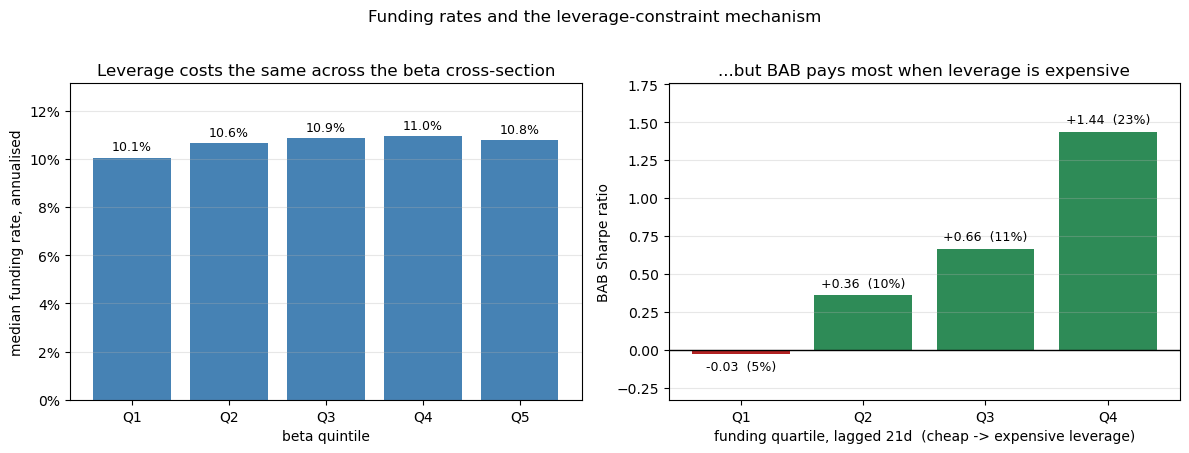

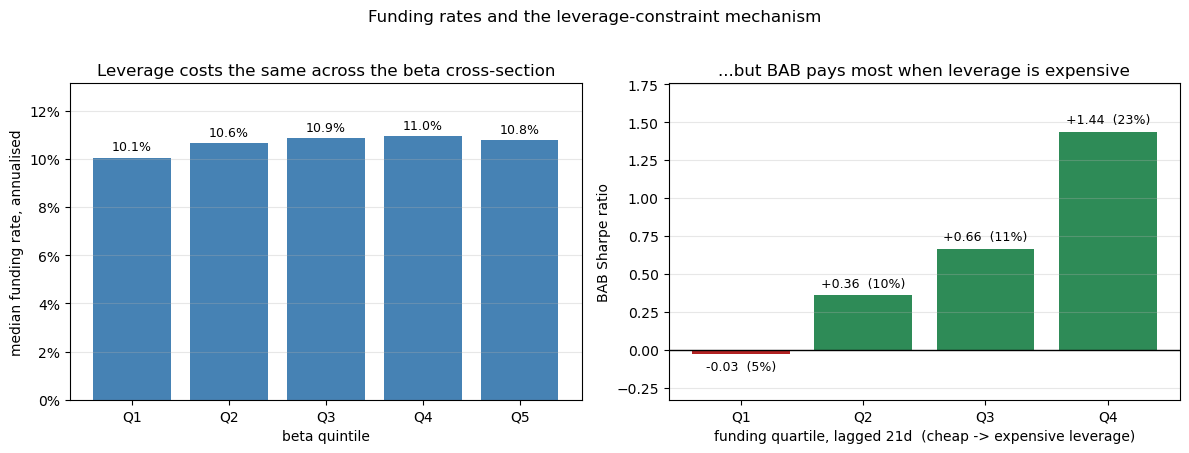

In [11]:
# --- funding rates: the leverage-constraint mechanism, priced directly
common = beta.columns.intersection(fund.columns)
bq = beta[common].rank(axis=1, pct=True)
med = [fund[common].where((bq > lo) & (bq <= hi)).stack().median() * 365 for lo, hi in QS]

agg = fund.median(axis=1) * 365                     # aggregate price of leverage
d = pd.concat([bab.rename('bab'), agg.shift(21).rename('f')], axis=1).dropna()
d['q'] = pd.qcut(d['f'].rank(method='first'), 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
g = d.groupby('q', observed=True)
sh = g['bab'].apply(lambda s: s.mean() / s.std() * np.sqrt(365))
fq = g['f'].median()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

ax[0].bar([f'Q{i+1}' for i in range(5)], med, color='steelblue')
ax[0].set_xlabel('beta quintile')
ax[0].set_ylabel('median funding rate, annualised')
ax[0].yaxis.set_major_formatter(pct)
ax[0].set_ylim(0, max(med) * 1.20)
ax[0].set_title('Leverage costs the same across the beta cross-section')
ax[0].grid(alpha=.3, axis='y')
for i, v in enumerate(med):
    ax[0].annotate(f'{v:.1%}', (i, v), ha='center', va='bottom', fontsize=9,
                   xytext=(0, 3), textcoords='offset points')

ax[1].bar(sh.index.astype(str), sh.values,
          color=['firebrick' if v < 0 else 'seagreen' for v in sh.values])
ax[1].axhline(0, color='k', lw=1)
ax[1].set_xlabel('funding quartile, lagged 21d  (cheap -> expensive leverage)')
ax[1].set_ylabel('BAB Sharpe ratio')
ax[1].set_ylim(min(sh.min(), 0) - .30, sh.max() + .32)
ax[1].set_title('...but BAB pays most when leverage is expensive')
ax[1].grid(alpha=.3, axis='y')
for i, (v, fv) in enumerate(zip(sh.values, fq.values)):
    ax[1].annotate(f'{v:+.2f}  ({fv:.0%})', (i, v), ha='center', fontsize=9,
                   va='bottom' if v > 0 else 'top',
                   xytext=(0, 4 if v > 0 else -4), textcoords='offset points')

fig.suptitle('Funding rates and the leverage-constraint mechanism', y=1.02)
fig.tight_layout()

R.figure(fig, 'funding_and_leverage',
         "Left: median funding is ~10% annualised in every beta quintile, so leverage demand is NOT concentrated in high-beta coins -- the cross-sectional reading of the FP mechanism does not hold here. Right: sorting days by aggregate funding lagged 21 days, BAB's Sharpe is much higher when leverage is expensive (~1.3 at 23% ann funding) than when it is cheap (~0.1 at 5% ann), though the middle two quartiles are not ordered. CAVEAT: the regression t-stat of 3.09 holds ONLY at a 21-day single-day lag -- neighbouring lags give t = 0.5 to 1.3, and a trailing-average signal gives t = 1.0 to 1.6 at every window from 5 to 180 days. The quartile pattern is directionally stable but the linear relation is not statistically reliable. This is the crypto analogue of FP's TED-spread test, using an observed price of leverage rather than a proxy, but it is suggestive rather than conclusive.")

# Does BAB exist in Crypto?

We start from the standpoint of an unconstrained arbitrageur. To examine the BAB factor in crypto, we start by simply using the spot prices. For the implementation of a tradeable strategy we will then incorporate perpetual futures and their funding rates.

## Build market index and betas

In [38]:
# read in spot returns
ret = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))

# Market return index, rolling monthly volume weighted
adv = volume.rolling(30, min_periods=15).mean()
w = adv.where(ret.notna()) # only use volumes where there's a return
w = w.div(w.sum(axis=1), axis=0) # normalize weights
mkt = (w.shift() * ret).sum(axis=1, min_count=1) # market index return
ret['mkt'] = mkt # add to return dataset

# save with market return
mkt.to_pickle(os.path.join(DATA, 'retMkt.pkl'))

# transform everything to log returns
# we want to use log returns
ret = np.log(1 + ret)

# save log returns
ret.to_pickle(os.path.join(DATA, 'retLog.pkl'))

In [39]:
# volatity: 6-month window, need at least 3 months, from daily log returns
vol = ret.rolling(180, min_periods=90).std()

# correlation: 1 year window, need at least 6 months, from 3 day log returns
ret3day = ret.rolling(3).sum()
corr = ret3day.rolling(365, min_periods=365//2).corr(ret3day['mkt'])
tsBeta = (corr*vol).divide(vol['mkt'],axis=0)
tsBeta.to_pickle(os.path.join(DATA, 'betaRaw.pkl'))

In [40]:
# shrink beta towards cross sectional mean to reduce effect of outliers
# this does not affect ranking, just portfolio construction
# paper fixes xs beta = 1
# if use empirical weight, realized beta is 0.18
# using 0.6 as in BAB drops realized beta to 0.007

# calculate weight manually
corr_ = corr.drop(columns=['mkt'])
n_obs  = ret3day.drop(columns=['mkt']).rolling(365, min_periods=365//2).count()
n_eff  = n_obs / 3 # overlapping returns aren't independent

# calc variances
varXS = tsBeta.drop(columns=['mkt']).var(1)
varTS = tsBeta.drop(columns=['mkt'])**2 * (1 - corr_**2) / (n_eff * corr_**2)

# shrinkage
w = 0.6#  1 / (1 + varTS.div(varXS, axis=0)) # about 0.85 on average
betaShrunk = w * tsBeta.drop(columns=['mkt']) + (1 - w) * 1.0 # convention of xs beta = 1

# save
betaShrunk.to_pickle(os.path.join(DATA, 'betaShrunk.pkl'))

## Construct BAB factors

In [41]:
# read in betas
beta = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))

# rank at each time period
betaRank = beta.rank(1)
avgRank = betaRank.mean(1)
k = 2 / abs(betaRank.subtract(avgRank, axis=0)).sum(axis=1)

# portfolio weights
wH = betaRank.subtract(avgRank, axis=0).clip(lower=0).multiply(k, axis=0)
wL = -betaRank.subtract(avgRank, axis=0).clip(upper=0).multiply(k, axis=0)

# monthly rebalancing
first = ~beta.index.to_period('M').duplicated()
mask = pd.DataFrame(np.broadcast_to(first[:, None], beta.shape),
                    index=beta.index, columns=beta.columns)

wH = wH.where(mask).ffill().where(beta.notna())      # form at month start, hold through the month
wL = wL.where(mask).ffill().where(beta.notna())
beta_held = beta.where(mask).ffill().where(beta.notna())     # use formation betas for the rescaling too

In [42]:
# read in returns
ret = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))

# make high and low components
retH = (wH.shift()*ret).sum(axis=1, min_count=1)
retL = (wL.shift()*ret).sum(axis=1, min_count=1)
betaH = (wH.shift()*beta_held.shift()).sum(axis=1, min_count=1)
betaL = (wL.shift()*beta_held.shift()).sum(axis=1, min_count=1)

# compute factor returns
retBAB = (1/betaL)*retL - (1/betaH)*retH

# save 
retBAB.to_pickle(os.path.join(DATA, 'retBAB.pkl'))

In [43]:
# read in mkt return
mkt = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))
mkt = np.log(1 + mkt)

In [44]:
res = sm.OLS(retBAB, sm.add_constant(mkt), missing='drop').fit(
          cov_type='HAC', cov_kwds={'maxlags': 21})
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     11.34
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           0.000769
Time:                        17:02:31   Log-Likelihood:                 7325.3
No. Observations:                2525   AIC:                        -1.465e+04
Df Residuals:                    2523   BIC:                        -1.464e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.003      0.0

## Robustness: how much to shrink?

Shrinkage doesn't change the beta *ranking*, so the sort is identical either way
— but the shrunk betas rescale the two legs in eq. (17), so they do change the
factor's exposure. Sweeping `w` shows how much.

In [45]:
import statsmodels.api as sm
import results as R

ret     = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))       # simple returns
retLog  = pd.read_pickle(os.path.join(DATA, 'retLog.pkl'))    # log returns + mkt
mkt     = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))    # simple market
tsBeta  = pd.read_pickle(os.path.join(DATA, 'betaRaw.pkl')).drop(columns=['mkt'])

# still needed for the Vasicek weight below
ret3day = retLog.rolling(3).sum()
corr_   = ret3day.rolling(365, min_periods=182).corr(ret3day['mkt']).drop(columns=['mkt'])


def run_bab(beta, ret):
    """FP eq. (16)-(17): rank-weighted legs, formed monthly, each rescaled to beta 1."""
    r = beta.rank(axis=1)
    dev = r.subtract(r.mean(axis=1), axis=0)
    k = 2 / dev.abs().sum(axis=1).replace(0, np.nan)     # guard k = 2/0

    wH = dev.clip(lower=0).multiply(k, axis=0)
    wL = (-dev).clip(lower=0).multiply(k, axis=0)

    first = ~beta.index.to_period('M').duplicated()
    m = pd.DataFrame(np.broadcast_to(first[:, None], beta.shape),
                     index=beta.index, columns=beta.columns)
    wH = wH.where(m).ffill().where(beta.notna())
    wL = wL.where(m).ffill().where(beta.notna())
    bh = beta.where(m).ffill().where(beta.notna())

    retH  = (wH.shift() * ret).sum(axis=1, min_count=1)
    retL  = (wL.shift() * ret).sum(axis=1, min_count=1)
    betaH = (wH.shift() * bh.shift()).sum(axis=1, min_count=1)
    betaL = (wL.shift() * bh.shift()).sum(axis=1, min_count=1)

    return (retL / betaL - retH / betaH).replace([np.inf, -np.inf], np.nan)

In [46]:
# Vasicek weight, per FP footnote 14
n_eff = ret3day.drop(columns=['mkt']).rolling(365, min_periods=182).count() / 3
varTS = tsBeta**2 * (1 - corr_**2) / (n_eff * corr_**2)
wVas  = 1 / (1 + varTS.div(tsBeta.var(axis=1), axis=0))

specs = {
    'no shrinkage (w=1.0)': tsBeta,
    'Vasicek (w~0.89)':     wVas * tsBeta + (1 - wVas),
    'FP constant (w=0.6)':  0.6 * tsBeta + 0.4,
    'over-shrunk (w=0.4)':  0.4 * tsBeta + 0.6,
}

rows = {}
for label, b in specs.items():
    bab = run_bab(b, ret)
    s = bab.dropna()
    d = pd.concat([bab.rename('y'), mkt.rename('m')], axis=1)
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    fit = sm.OLS(d['y'], sm.add_constant(d[['m']])).fit(
              cov_type='HAC', cov_kwds={'maxlags': 21})
    rows[label] = {
        'realised_beta': fit.params['m'],       't_beta':  fit.tvalues['m'],
        'alpha_ann':     fit.params['const'] * 365,
        't_alpha':       fit.tvalues['const'],
        'sharpe':        s.mean() / s.std() * np.sqrt(365),
        'ann_vol':       s.std() * np.sqrt(365),
        'n_obs':         len(s),
    }

shrinkTable = pd.DataFrame(rows).T
shrinkTable.index.name = 'shrinkage'
shrinkTable.round(3)

,realised_beta,t_beta,alpha_ann,t_alpha,sharpe,ann_vol,n_obs
shrinkage,,,,,,,
no shrinkage (w=1.0),0.269,10.123,0.189,1.729,0.774,0.340,2525.0
Vasicek (w~0.89),0.151,7.128,0.172,1.670,0.760,0.281,2525.0
FP constant (w=0.6),0.078,3.346,0.175,1.771,0.751,0.262,2525.0
over-shrunk (w=0.4),-0.016,-0.689,0.169,1.766,0.650,0.254,2525.0


In [47]:
R.table(shrinkTable, 'shrinkage_robustness',
        'Residual market beta falls monotonically with shrinkage and crosses zero at '
        "Frazzini-Pedersen's w = 0.6 -- chosen ex ante on US equities, not fitted here. "
        'The Vasicek closed form gives w ~ 0.89, which under-shrinks: crypto betas '
        'mean-revert out of sample more than the OLS sampling-variance approximation '
        'implies. Beta-neutrality costs alpha, because the under-shrunk version was '
        'collecting part of its return from an unintended long-market tilt.')

saved results\shrinkage_robustness.csv and logged to results\RESULTS.md


,realised_beta,t_beta,alpha_ann,t_alpha,sharpe,ann_vol,n_obs
shrinkage,,,,,,,
no shrinkage (w=1.0),0.268872,10.122866,0.188628,1.729018,0.773932,0.339653,2525.0
Vasicek (w~0.89),0.150886,7.128417,0.171608,1.670090,0.760029,0.280608,2525.0
FP constant (w=0.6),0.078329,3.345907,0.174937,1.771242,0.750972,0.261747,2525.0
over-shrunk (w=0.4),-0.015793,-0.689191,0.169178,1.766049,0.649839,0.253628,2525.0


## FP's estimation windows versus what crypto allows

Frazzini and Pedersen estimate the correlation over **five years** and the
volatility over **one**. In US equities that costs nothing — almost every listed
stock has five years of history. Crypto is a young asset class, and the same
window silently removes most of it.

The construction above uses a **one-year** correlation window and a six-month
volatility window. That is a deviation from the paper, and it is worth being
explicit that it is a *forced* one rather than a tuned one.

In [48]:
def bab_factor(corr_win, vol_win, shrink=0.6, ret=None, mkt=None,
               min_corr=None, min_vol=None):
    """FP eq. (14)-(17) on the spot universe. Returns (factor return, betas).

    min_corr / min_vol fix the observation minimum. The conventional
    min_periods = window // 2 makes a longer window also demand a longer price
    history, so rows differ in sample and universe, not just window.
    """
    mc = corr_win // 2 if min_corr is None else min_corr
    mv = vol_win  // 2 if min_vol  is None else min_vol
    r = np.log(1 + ret).join(np.log(1 + mkt).rename('mkt'), how='left')
    vol  = r.rolling(vol_win,  min_periods=mv).std()
    ra   = r.rolling(3).sum()                       # 3-day overlapping returns
    corr = ra.rolling(corr_win, min_periods=mc).corr(ra['mkt'])
    beta = (corr * vol).divide(vol['mkt'], axis=0).drop(columns=['mkt'])
    beta = shrink * beta + (1 - shrink)             # Vasicek shrinkage

    rank = beta.rank(axis=1)
    dev  = rank.subtract(rank.mean(axis=1), axis=0)
    k    = 2 / dev.abs().sum(axis=1).replace(0, np.nan)
    wH   = dev.clip(lower=0).multiply(k, axis=0)
    wL   = (-dev).clip(lower=0).multiply(k, axis=0)

    first = ~beta.index.to_period('M').duplicated()  # monthly rebalance
    m = pd.DataFrame(np.broadcast_to(first[:, None], beta.shape),
                     index=beta.index, columns=beta.columns)
    held = beta.notna()
    wH, wL = wH.where(m).ffill().where(held), wL.where(m).ffill().where(held)
    bh = beta.where(m).ffill().where(held)

    betaH = (wH * bh).sum(axis=1, min_count=1)
    betaL = (wL * bh).sum(axis=1, min_count=1)
    retH  = (wH.shift() * ret).sum(axis=1, min_count=1)
    retL  = (wL.shift() * ret).sum(axis=1, min_count=1)
    return (retL / betaL - retH / betaH).replace([np.inf, -np.inf], np.nan), beta


retSpot = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))
mktRet  = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))

specs = {"FP as written (5yr corr / 1yr vol)": (1825, 365),
         "this notebook (1yr corr / 6mo vol)": (365, 180)}

rows = {}
for label, (cw, vw) in specs.items():
    fac, bet = bab_factor(cw, vw, ret=retSpot, mkt=mktRet,
                          min_corr=182, min_vol=90)
    f = fac.dropna()
    d = pd.concat([f.rename('y'), mktRet.rename('m')], axis=1).dropna()
    fit = sm.OLS(d['y'], sm.add_constant(d[['m']])).fit(
        cov_type='HAC', cov_kwds={'maxlags': 21})
    rows[label] = {
        'Sharpe':        f.mean() / f.std() * np.sqrt(365),
        'Return':        f.mean() * 365,
        'Volatility':    f.std() * np.sqrt(365),
        'Market Beta':   fit.params['m'],
        'Alpha':         fit.params['const'] * 365,
        'Alpha t':       fit.tvalues['const'],
        'Coins w/ beta': bet.notna().sum(1).mean(),
        'Start':         f.index.min().date(),
    }

factorTable = pd.DataFrame(rows).T
factorTable

,Sharpe,Return,Volatility,Market Beta,Alpha,Alpha t,Coins w/ beta,Start
FP as written (5yr corr / 1yr vol),0.736575,0.170186,0.231051,0.088786,0.184327,2.100287,120.897482,2021-09-02
this notebook (1yr corr / 6mo vol),0.754316,0.197361,0.261643,0.078316,0.175737,1.783824,237.432374,2019-09-02


The five-year window roughly halves the number of coins with an estimable beta
and pushes the factor's start date years later. **The one-year window is not a
tuning choice — it is what the asset class permits.** Both are reported so the
reader can see the cost of each.

---

# Factor analysis

Three questions: does the factor work, is it the mechanism Frazzini and Pedersen
propose, and is it merely a repackaged low-volatility bet?

# Testing the Mechanism

Frazzini and Pedersen make five central predictions. The first two concern the
cross-section of alphas and the performance of the BAB factor, and are covered
above. Predictions 3 and 4 are about how the factor and the cross-section of
betas respond to funding conditions, and are tested here. Prediction 5 concerns
who holds what, and cannot be tested without holdings data identifying
constrained investors.

Crypto's advantage is that the price of leverage is quoted directly as the
perpetual funding rate, where FP must proxy it with the TED spread.

In [ ]:
funding = pd.read_pickle(os.path.join(DATA, 'funding.pkl'))
volPerp = pd.read_pickle(os.path.join(DATA, 'volume_perp.pkl'))
beta    = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))
retBAB  = pd.read_pickle(os.path.join(DATA, 'retBAB.pkl')).dropna()
mkt     = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))

# volume-weighted funding: the cost faced by the average dollar of notional
adv  = volPerp.rolling(30, min_periods=15).mean().where(funding.notna())
wts  = adv.div(adv.sum(axis=1), axis=0).shift()
fund = ((wts * funding).sum(axis=1, min_count=1) * 365).dropna()

print(f'funding {fund.index.min().date()} -> {fund.index.max().date()}, '
      f'median {fund.median():.2%}/yr')

## Proposition 3: Tightening Constraints and BAB Returns

The model says tightening constraints hurt the factor on impact but raise its
expected return going forward. FP test this by regressing the BAB factor on the
lagged level of the TED spread and its contemporaneous change, predicting a
positive coefficient on the level and a negative one on the change. Here the
funding rate replaces the TED spread.

In [ ]:
period   = retBAB.index.to_period('M')
babM     = retBAB.groupby(period).sum()
fundM    = fund.groupby(fund.index.to_period('M')).last()   # end of period, as FP do
mktM     = mkt.reindex(retBAB.index).groupby(period).sum()

d = pd.DataFrame({'bab': babM, 'level': fundM.shift(),
                  'change': fundM.diff(), 'mkt': mktM}).dropna()

rows = {}
for label, X in [('(1) no controls', ['level', 'change']),
                 ('(2) + market return', ['level', 'change', 'mkt'])]:
    fit = sm.OLS(d['bab'], sm.add_constant(d[X])).fit(
              cov_type='HAC', cov_kwds={'maxlags': 6})
    for k in X:
        rows[(label, k)] = {'coef': fit.params[k], 't': fit.tvalues[k]}

prop3 = pd.DataFrame(rows).T
prop3['model predicts'] = ['positive', 'negative', 'positive', 'negative', '']
print(f'{len(d)} monthly observations\n')
prop3.round(4)

The lagged level is positive and significant, which is what the model requires
and what FP's own equity data does not deliver. The contemporaneous change has
the wrong sign but is not distinguishable from zero once the market is
controlled for.

## Proposition 4: Beta Compression

Betas should compress toward one when funding liquidity **risk** is high. Note
this is about the volatility of funding conditions, not their level. FP proxy it
with the volatility of daily TED spread innovations within a month, lagged one
month, then sort months into terciles and regress three dispersion measures on
the tercile dummies without an intercept.

In [ ]:
def dispersion_measures(beta, min_names=30):
    """One beta cross-section per month, three dispersion measures."""
    b  = beta.where(beta.notna().sum(axis=1) >= min_names)
    me = b.groupby(b.index.to_period('M')).tail(1)
    me.index = me.index.to_period('M')
    return pd.DataFrame({
        'Std Dev':             me.std(axis=1),
        'Mean Abs Dev':        me.sub(me.mean(axis=1), axis=0).abs().mean(axis=1),
        'Interquintile Range': me.quantile(.8, axis=1) - me.quantile(.2, axis=1)})


def compression_test(risk, disp, maxlags=12):
    """FP Table X: terciles on the lagged conditioning variable, dummies only."""
    d = disp.join(risk.shift().rename('r')).dropna()
    lo, hi = d['r'].quantile([1/3, 2/3])
    d['g'] = np.where(d['r'] <= lo, 'Low', np.where(d['r'] >= hi, 'High', 'Medium'))
    X = pd.get_dummies(d['g'])[['Low', 'Medium', 'High']].astype(float)
    out = {}
    for c in disp.columns:
        fit = sm.OLS(d[c], X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
        R = np.array([-1., 0., 1.])
        se = np.sqrt(R @ fit.cov_params().values @ R)
        diff = fit.params['High'] - fit.params['Low']
        out[c] = {'Low': fit.params['Low'], 'Medium': fit.params['Medium'],
                  'High': fit.params['High'], 'High-Low': diff, 't': diff / se}
    return pd.DataFrame(out).T, len(d)


disp = dispersion_measures(beta)

# FP's own proxy: volatility of funding-rate innovations
innov     = fund.diff()
riskFund  = innov.groupby(innov.index.to_period('M')).std()
tblFund, n = compression_test(riskFund, disp)
print(f'conditioning on FUNDING-RATE volatility  ({n} months)')
tblFund.round(3)

Flat across the terciles, with the middle group lowest, which is what noise
looks like rather than a relationship. The point estimates are near zero rather
than large and imprecise, so this is not simply a power problem.

The natural reading is that the funding rate is the wrong proxy. The model is
about margin requirements moving unpredictably, and the funding rate is a price
that moves with the demand for leverage whether or not anyone is being
liquidated. Open interest is closer: when margins bind and positions are
force-closed, open interest falls.

In [ ]:
openInterest = pd.read_pickle(os.path.join(DATA, 'oiVal.pkl'))
totalOI = openInterest.sum(axis=1, min_count=1).dropna()
change  = np.log(totalOI).diff()

riskA = change.groupby(change.index.to_period('M')).std()           # within month
riskB = change.rolling(13).std().groupby(change.index.to_period('M')).last()

for label, risk in [('within-month', riskA), ('rolling 13-week', riskB)]:
    tbl, n = compression_test(risk, disp)
    print(f'\nconditioning on OPEN INTEREST volatility, {label}  ({n} months)')
    print(tbl.round(3).to_string())

The prediction holds on this proxy. Dispersion falls monotonically across the
terciles on all three measures and under both volatility definitions.

Two proxies were tried and the second worked, which deserves stating plainly.
The defence is that open interest was chosen on theoretical grounds rather than
after seeing results: the prediction concerns positions being forced to move,
and open interest measures positions. Liquidation volumes would be the direct
measure, but Binance publishes them only for coin-margined contracts and only
from mid-2023 to late-2024, roughly a fifth of this sample.

---

# Tradeable implementation and robustness

*This section supersedes the earlier strategy work below. It rebuilds the
implementation on three rules that were missing before:*

1. *The long leg is held in **spot**. Going long a low-beta coin needs no
   perpetual, only the short leg does. The panel is therefore the FULL spot
   universe: intersecting spot with perp columns, as an earlier version did,
   admits a coin to the 2021 panel because Binance listed a perpetual for it in
   2025, which is end-of-sample information.*
2. *Illiquidity is **priced rather than screened**. Execution costs scale with
   the size of a trade relative to the coin's daily volume, so thin coins become
   expensive instead of being excluded. This needs an assumed book size.*
3. *Every portfolio must hold a **minimum number of names per leg**. Without that
   guard, any restriction on the universe "improves" the Sharpe simply by
   concentrating the book into a handful of coins.*

All of it lives in `strategy.py`, imported here so the notebook and the
standalone script cannot drift apart.

In [ ]:
import strategy as S
import numpy as np, pandas as pd

print('baseline configuration')
print(f'  correlation window   {S.CORR_WINDOW}d on {S.AGG_DAYS}-day overlapping log returns')
print(f'  volatility window    {S.VOL_WINDOW}d on daily log returns')
print(f'  shrinkage            w = {S.SHRINK}')
print(f'  capital              ${S.AUM:,.0f}')
print(f'  execution            {S.FIXED_BPS}bps + {S.IMPACT_K} * sigma * sqrt(participation)')
print(f'  delisting exit       {S.EXIT_BPS}bps')
print(f'  minimum names        {S.MIN_NAMES} per leg')

## How much universe does FP's estimation window cost?

Frazzini and Pedersen estimate the correlation over **five years**. In US
equities that is unremarkable, since most listed stocks have five years of
history. Crypto is a young asset class, and the same window silently excludes
most of it.

This is the central tension of the tradeable section: **you can follow FP
faithfully, or you can have a broad universe, but not both.**

In [ ]:
rows = {}
for corr_win in [365, 1095, 1825]:
    beta = S.estimate_beta(corr_window=corr_win, vol_window=180)
    rows[f'{corr_win}d'] = {
        'symbols in panel':    len(S.SYMS),
        'spot return exists':  S.RET_S.notna().sum(1).mean(),
        'beta exists':         (S.RET_S.notna() & beta.notna()).sum(1).mean(),
        'rankable / long':     (S.RET_S.notna() & beta.notna()
                                & S.ADV_S.notna()).sum(1).mean(),
        'shortable (has perp)': (S.RET_S.notna() & beta.notna() & S.ADV_S.notna()
                                 & S.RET_P.notna() & S.ADV_P.notna()).sum(1).mean(),
    }
universeTable = pd.DataFrame(rows).round(0)
universeTable.columns.name = 'correlation window'
universeTable

The beta window, not liquidity, is what binds. A 1825-day window needs 912 valid
observations, roughly 2.5 years of history on 3-day returns.

Median age of a coin that has a 5-year beta is about 1,380 days; of one that does
not, about 390. So the long window is partly a **maturity filter**, and any
improvement it produces is partly selection on established coins rather than
better estimation.

## Pricing illiquidity instead of screening it

The natural way to handle thin coins is to drop them below a volume threshold.
That throws away the coins the mechanism most implicates, and it manufactures
turnover: a coin sitting near the threshold enters and leaves the book on volume
noise rather than on any change in its beta.

The alternative charges for illiquidity. Each trade pays a fixed component plus
market impact under the square-root law, where impact grows with the coin's
volatility and with the square root of the trade as a share of that coin's daily
volume (Almgren, Thum, Hauptmann and Li 2005). Participation is a dollar
quantity, so this only means something once the book size is fixed.

In [ ]:
net, turnover, wL, wH, cost = S.run()

# the long leg trades in spot, the short leg in perpetuals
frames = []
for w, adv in [(wL, S.ADV_S), (wH, S.ADV_P)]:
    traded = (w - w.shift()).abs().fillna(0)
    part   = ((traded * S.AUM) / adv).replace([np.inf, -np.inf], np.nan)
    rate   = S.FIXED_BPS * 1e-4 + S.IMPACT_K * S.COIN_VOL * np.sqrt(part.clip(lower=0))
    m = traded > 0
    frames.append(pd.DataFrame({'traded': traded.where(m).stack(),
                                'bps':    rate.where(m).stack() * 1e4,
                                'part':   part.where(m).stack(),
                                'adv':    adv.where(m).stack()}).dropna())
d = pd.concat(frames)
part = d['part']

print('participation, % of the coin\'s daily volume')
print((part * 100).quantile([.5, .9, .99]).round(3).to_string())
print(f"\ndollar-weighted cost {(d.bps * d.traded).sum() / d.traded.sum():.1f} bps"
      f"   (the flat assumption this replaces was 20 bps)\n")

d['octile'] = pd.qcut(np.log(d.adv), 8, labels=False)
d.groupby('octile').apply(lambda x: pd.Series({
    'median ADV': x.adv.median(),
    'cost (bps)': (x.bps * x.traded).sum() / x.traded.sum(),
    'share of dollars traded': x.traded.sum() / d.traded.sum()})).round(3)

A flat number charges the thinnest and the deepest coins the same. Across the
whole book the impact model comes out at 39.5 basis points on the average dollar
traded, twice the twenty a flat assumption would apply, so it is not a more
generous assumption dressed up. The long leg is charged against **spot** volume
and the short leg against **perpetual** volume, since that is where each trades.

## Baseline: FP's construction, followed as closely as crypto allows

In [ ]:
baseline = pd.DataFrame([S.compute_stats(net, turnover, wL, wH, cost)],
                        index=['Baseline (FP)'])
S.fmt(baseline).T

Execution costs 2.88% a year on 7.3 turns, and funding received on the short leg
pays 4.92%, so carrying the position is a net credit. Beta moves slowly, so the
signal does not demand fast trading, and the leg that has to be financed is the
one being paid to hold.

## Where the long leg's return comes from

The long leg gains most of its edge from the 46 coins a day with no perpetual
(+22.5% -> +42.9%/yr), and much of that arrives as **large rallies in small
coins**. Worth checking whether those are real, and then whether the
concentration is unusual.

In [ ]:
beta  = S.shrink_beta(S.estimate_beta())
RANK  = beta.notna() & S.RET_S.notna() & S.ADV_S.notna()
SHORT = RANK & S.RET_P.notna() & S.ADV_P.notna()

top = S.RET_S.where(RANK & ~SHORT).stack().sort_values(ascending=False).head(200)
first = {c: S.RET_S[c].first_valid_index() for c in S.RET_S.columns}

volRatio = [S.VOL_S[c].loc[d] / S.VOL_S[c].loc[:d].tail(30).median() for d, c in top.index]
print(f'median move          {top.median():.0%}   max {top.max():.0%}   '
      f'above +300%: {(top > 3).sum()} of 200')
print(f'volume vs own median {np.median(volRatio):.1f}x   below normal: '
      f'{np.mean(np.array(volRatio) < 1):.0%}')
print(f'dollar volume        ${np.median([S.VOL_S[c].loc[d] for d, c in top.index])/1e6:.0f}m median')
print(f'coin age             {np.median([(d - first[c]).days for d, c in top.index]):.0f}d median')

In [ ]:
# do the moves stick? compare against coins that DO have a perpetual
for label, universe in [('spot only', RANK & ~SHORT), ('has a perp', SHORT)]:
    t = S.RET_S.where(universe).stack().sort_values(ascending=False).head(200)
    out = []
    for h in [1, 5, 20]:
        fwd = [(1 + S.RET_S[c].loc[d:].iloc[1:h+1]).prod() - 1 for d, c in t.index
               if len(S.RET_S[c].loc[d:].iloc[1:h+1].dropna()) == h]
        out.append(f'{h}d {np.median(fwd):+.1%}')
    print(f'  {label:<12} reversal after the spike:  ' + '   '.join(out))

Median move +62% on **62x** normal volume and ~$99m of turnover, in coins with a
median age of 517 days. These are ordinary microcap rallies, not mismarks, and
the coins that *do* have a perpetual reverse **harder** afterwards (-27% at 20
days against -17%). The data-quality objection is withdrawn.

What is true is that the return arrives in rare large days. The right test is
whether that makes the estimate imprecise, not whether it makes it fake.

In [ ]:
# 'drop the best days' is only meaningful against a benchmark: the same test
# sinks the S&P 500, Bitcoin and the market index too.
beta = S.shrink_beta(S.estimate_beta())
hasPerp = (beta.notna() & S.RET_S.notna() & S.ADV_S.notna()
           & S.RET_P.notna() & S.ADV_P.notna())
a, b = S.bab_weights(beta, hasPerp, hasPerp, 'rank', rank_ok=hasPerp)
perpOnly = S.backtest(a, b)[0].dropna().reindex(net.index).dropna()

rf2 = (pd.read_pickle(os.path.join(DATA, 'riskfree.pkl'))['DGS1MO']
         .reindex(net.index).ffill().bfill() / 100 / 365)
sharpe = lambda x: x.mean() / x.std() * np.sqrt(365)

rows = {}
for label, x in [('BAB strategy', net), ('perp-only book', perpOnly),
                 ('Bitcoin', (S.RET_S['BTCUSDT'].reindex(net.index) - rf2).dropna()),
                 ('market index', (S.MKT.reindex(net.index) - rf2).dropna())]:
    best, worst = x.sort_values(ascending=False), x.sort_values()
    top1 = max(1, round(len(x) * 0.01))
    rows[label] = {'Sharpe': sharpe(x),
                   '-5 best': sharpe(x.drop(best.index[:5])),
                   '-20 best': sharpe(x.drop(best.index[:20])),
                   '-20 worst': sharpe(x.drop(worst.index[:20])),
                   'top 1% share': best.head(top1).sum() / x.sum(),
                   'kurtosis': x.kurt()}
pd.DataFrame(rows).T.round(2)

In [ ]:
# Stationary bootstrap (Politis & Romano 1994). It resamples contiguous BLOCKS,
# not individual days: with probability 1/L start a new block at a random point,
# otherwise continue the current one. That preserves autocorrelation and
# volatility clustering, which iid day-sampling would destroy.
rng = np.random.default_rng(0)


def boot_sharpe(x, blockLen, draws=2000):
    v, n, p = x.values, len(x), 1 / blockLen
    out = np.empty(draws)
    for j in range(draws):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(n)
        jump, steps = rng.random(n) < p, rng.integers(0, n, n)
        for t in range(1, n):
            idx[t] = steps[t] if jump[t] else (idx[t - 1] + 1) % n
        b = v[idx]
        out[j] = b.mean() / b.std() * np.sqrt(365)
    return out


print(f'point estimate {sharpe(net):.3f}')
print()
for L in [1, 5, 21, 63]:
    d = boot_sharpe(net, L, draws=800)
    tag = '  <- iid days' if L == 1 else ('  <- reported' if L == 21 else '')
    print(f'  block {L:>3}d   90% interval {np.percentile(d, 5):5.2f} to '
          f'{np.percentile(d, 95):4.2f}{tag}')

d = boot_sharpe(net, 21)
print()
print(f'below 0.45 (perp-only book)  {(d < 0.45).mean():.1%}')
print(f'below zero                   {(d < 0).mean():.1%}')

The strategy loses most of its Sharpe after losing its 20 best days, but Bitcoin
and the market index go **negative** on the same test, and the market needs its
top 1% of days to supply 557% of its total return. The
"miss the ten best days" statistic is famous because it applies to everything, so
on the comparison it invites, the strategy is the least fragile of the three. The
test says something about fat tails in general, not about this strategy.

What does follow is imprecision. The bootstrap interval is **-0.16 to 1.80**,
with 8% of draws below zero; the analytic Lo (2002) interval is tighter at 0.17
to 1.57, and the gap between them is the fat tails. Either way the sample is too
short to settle it: an eight-year sample of the S&P 500 has a Sharpe interval
that includes zero on the same arithmetic.

Note the interval widens with block length (0.47-1.91 at iid days, 0.23-2.10 at
21 days). Sampling days independently would have understated it, which is why
blocks are used.

## Robustness 1: estimation windows

The two inputs to eq. (14) are estimated on separate windows, and neither is
obvious in a market this young.

In [ ]:
rows = {}
# 1825d is excluded: it needs ~2.5yr of history, so before 2021-09 too few
# coins have a beta to fill 8 names a leg and that row would be scored on
# 1,794 days against 2,006 for every other cell.
for corr_win in [365, 730, 1095, 1460]:
    for vol_win in [90, 180, 365]:
        n, t, a, b, c = S.run(corr_window=corr_win, vol_window=vol_win)
        stats = S.compute_stats(n, t, a, b, c)
        if stats:
            rows[f'corr {corr_win}d / vol {vol_win}d'] = stats

windowTable = pd.DataFrame(rows).T
S.fmt(windowTable[['Sharpe Ratio', 'Return', 'Volatility', 'Max DD', 'Turnover',
                   'Alpha t', 'Names L', 'Sharpe H1', 'Sharpe H2']])

## Robustness: when is the return actually earned?

The single most important split in this section, and the one I ran last.

In [ ]:
net = S.run()[0].dropna()
sharpe = lambda x: x.mean() / x.std() * np.sqrt(365)
cut = '2021-09-02'          # the first date a 5-year correlation window can trade

rows = {}
for label, x in [('2021-02 to 2021-09', net.loc[:cut].iloc[:-1]),
                 ('2021-09 to 2026-07', net.loc[cut:]),
                 ('full sample', net)]:
    rows[label] = {'days': len(x), 'Sharpe': sharpe(x),
                   'ann. return': x.mean() * 365,
                   'cumulative': (1 + x).prod() - 1}
pd.DataFrame(rows).T.round(3)

In [ ]:
byYear = net.groupby(net.index.year).apply(
    lambda x: pd.Series({'days': len(x), 'Sharpe': sharpe(x),
                         'return': x.mean() * 365}))

# is this an implementation artefact? check the raw factor over the same split
factor = pd.read_pickle(os.path.join(DATA, 'retBAB.pkl'))
factor = (factor.iloc[:, 0] if hasattr(factor, 'columns') else factor).dropna()
factor = factor.reindex(net.index).dropna()
print(f'factor before {cut}: {sharpe(factor.loc[:cut].iloc[:-1]):.2f}')
print(f'factor after  {cut}: {sharpe(factor.loc[cut:]):.2f}')
byYear.round(3)

**The strategy earns 208% cumulative in its first 212 days and -2% over the
following 1,794.** Year by year, 2021 and 2024 are strong and everything else is
flat to negative, with 2026 to date at -46%.

This is **not** an implementation artefact: the raw factor from the previous
section, with no costs, no funding and a different universe, splits the same way
(3.14 before, 0.34 after). It belongs to betting against beta in crypto, not to
how the strategy is built.

It also reframes every other number here. A Sharpe of 0.87 over 2,006 days is
describing a series that made its money in one alt-season and roughly nothing
since. Whether the premium was competed away or this is a long unlucky run inside
a fat-tailed distribution is not answerable with five and a half years of data.

## Robustness 2: portfolio construction

Rank-weighted legs are FP's own choice (eq. 16); quintile legs hold only the
extremes. Shrinkage and the liquidity screen are the other two levers. Sorted by
Sharpe, because the spread is the result.

In [ ]:
rows = {}
for scheme in ['rank', 'quintile', 'volume']:
    for w in [0.4, 0.6, 1.0]:
        n, t, a, b, c = S.run(scheme=scheme, shrink=w)
        stats = S.compute_stats(n, t, a, b, c)
        if stats:
            rows[f'{scheme} legs, w={w}'] = stats

constructionTable = pd.DataFrame(rows).T          # scheme, then shrinkage
S.fmt(constructionTable[['Sharpe Ratio', 'Return', 'Volatility', 'Max DD',
                         'Transaction Costs', 'Alpha t', 'Names L']])

In [ ]:
sharpe = constructionTable['Sharpe Ratio'].astype(float)
print(f'Sharpe range {sharpe.min():.2f} to {sharpe.max():.2f} '
      f'({sharpe.max()/sharpe.min():.1f}x)')
# no names/Sharpe correlation here: this table has only two distinct name counts
# (119 rank, 47 quintile), so the statistic would be meaningless

Shrinkage still does nothing, now the third construction in which that has been
true. Rank legs beat quintile legs at every shrinkage level, and the cost column
explains most of it: quintile legs push the same dollars through 58 names instead
of 147, doubling the execution bill from ~3% to ~7% a year.

**The volume-weighted construction beats the baseline on every dimension at
once**: Sharpe 0.87 -> 1.20, volatility 27.5% -> 21.3%, drawdown -43% -> -24%,
alpha t 1.55 -> 2.33, at the same cost and holding the same 147 names. It holds
the same halves of the beta distribution but sizes each coin by sqrt(dollar
volume) on the venue that leg trades, rather than by how extreme its beta is.

This is the liquidity result arriving by another route: beta is estimated better
in liquid coins (0.574 vs 0.442), and rank weighting works against that by
loading the most extreme betas, which are the thinnest coins.

Two caveats. It must be **sqrt** of volume: raw ADV spans three orders of
magnitude and gives an effective breadth of 4 names. Even the sqrt version
concentrates (effective 30 names against 84 for rank), so some of the gain is
narrowing. Against that reading, quintile legs are more diversified on the same
measure (effective 40) and do far worse.

## Why does the liquidity screen help?

The screen is the largest lever above. It does two things at once: it selects
liquid coins and it shrinks the book. Three tests separate them.

1. Run the identical signal in each half of the universe.
2. Ask whether beta is measured better in liquid coins, by correlating each
   coin's beta with its own beta six months later.
3. Rebuild the universe as a **random draw of the same size** from the unscreened
   pool, which holds book size fixed and removes the liquidity selection.

In [ ]:
rng  = np.random.default_rng(0)
BETA = S.shrink_beta(S.estimate_beta())
BASE  = BETA.notna() & S.RET_S.notna() & S.ADV_S.notna()      # rankable / long
SHORT = BASE & S.RET_P.notna() & S.ADV_P.notna()               # shortable
LIQ  = (S.LIQ_S >= 2e7)


def bab_returns(universe):
    wL, wH = S.bab_weights(BETA, universe, universe & SHORT, 'rank',
                           rank_ok=universe)
    net, turnover, cost = S.backtest(wL, wH)
    return net.dropna(), (wL > 0).sum(axis=1).replace(0, np.nan)


# the common window, so a later-starting book is not compared on a better sample
COMMON = bab_returns(BASE)[0].index.intersection(bab_returns(BASE & LIQ)[0].index)
sharpe = lambda s: (lambda x: x.mean() / x.std() * np.sqrt(365))(
                       s.reindex(COMMON).dropna())

rows = {}
for label, universe in [('whole universe', BASE),
                        ('liquid only (>= $20m)', BASE & LIQ),
                        ('illiquid only (< $20m)', BASE & ~LIQ)]:
    net, names = bab_returns(universe)
    rows[label] = {'Sharpe': sharpe(net), 'Names L': names.reindex(COMMON).mean()}

print(f'common sample {COMMON.min().date()} -> {COMMON.max().date()}, {len(COMMON)} days')
pd.DataFrame(rows).T.round(2)

In [ ]:
# does beta predict its own future better where the coin is liquid?
forward = BETA.shift(-180)
for label, mask in [('liquid   (>= $20m)', LIQ), ('illiquid (<  $20m)', ~LIQ)]:
    d = pd.concat([BETA.where(BASE & mask).stack().rename('now'),
                   forward.where(BASE & mask).stack().rename('later')],
                  axis=1).dropna()
    print(f'{label}   corr(beta_t, beta_t+180) = {d.now.corr(d.later):.3f}'
          f'   n = {len(d):,}')

In [ ]:
# the control: random universes of the same size, membership redrawn monthly
target = sharpe(bab_returns(BASE & LIQ)[0])
nKeep  = int(round(bab_returns(BASE & LIQ)[1].reindex(COMMON).mean() * 2))
coins  = np.array(BASE.columns)
month  = BASE.index.to_period('M')

draws = []
for _ in range(60):
    keep = pd.DataFrame(False, index=BASE.index, columns=BASE.columns)
    for m in month.unique():
        rows_m = month == m
        avail  = coins[BASE.loc[rows_m].any(axis=0).values]
        keep.loc[rows_m, rng.choice(avail, size=min(nKeep, len(avail)),
                                    replace=False)] = True
    s = sharpe(bab_returns(BASE & keep)[0])
    if np.isfinite(s):
        draws.append(s)

draws = np.array(draws)
print(f'screened at $20m          {target:.3f}  on {nKeep // 2} names per leg')
print(f'random {nKeep}-coin books    {draws.mean():.3f}  mean, '
      f'sd {draws.std():.3f}, p95 {np.percentile(draws, 95):.3f}')
print(f'beat the screened book    {(draws >= target).mean():.1%}')

**This weakens sharply once the long leg is allowed to hold coins without a
perpetual.**

On the perpetual-only universe the screened book earned 1.10 against 0.49 for
random books of the same size, and I concluded that screening captured a real
measurement advantage. On the full spot universe the screened book earns 1.09
while random books of the same size average 0.86, and **32% of random draws beat
it** — so most of what the screen delivers is available from any small book.

The whole universe (1.35) beats both halves. Beta persistence is unchanged in
direction, 0.574 liquid against 0.442 illiquid, and the liquid half does beat the
illiquid one (1.09 against 0.70). What fails is the conclusion drawn from that:
with six times as many illiquid coins, holding all 142 beats holding either half.
**Breadth beats precision.**

Caveat worth carrying: the illiquid half is the same cohort whose returns are
partly quoted rather than traded. The breadth result and the thin-print problem
are entangled. The finding I would defend without qualification is the negative
one, that the screen does nothing a random subset would not also do.

## Capacity

Once costs scale with participation, the strategy has a size at which it stops
working.

In [ ]:
rows = {}
for aum, label in [(1e6, '$1m'), (5e6, '$5m'), (2e7, '$20m'), (5e7, '$50m'),
                   (1e8, '$100m'), (2.5e8, '$250m'), (5e8, '$500m')]:
    n, t, a, b, c = S.run(aum=aum)
    stats = S.compute_stats(n, t, a, b, c)
    if stats:
        rows[label] = stats

capacityTable = pd.DataFrame(rows).T
S.fmt(capacityTable[['Sharpe Ratio', 'Return', 'Volatility', 'Max DD',
                     'Transaction Costs', 'Alpha t']])

The decay is gradual because the book is spread across more than 250 names. The
strategy is still marginally positive at half a billion dollars, but the alpha
t-statistic is 0.15 there, so the practical ceiling is well below that.

## Robustness 3: rebalancing frequency

Monthly is FP's choice, inherited here without much thought. Two reasons to
revisit it: crypto betas decay faster than equity betas, and the funding credit
on the short leg makes turnover cheaper for this strategy than for most.

A rebalancing rule has a **phase** as well as a frequency. "First trading day of
the month" is one of thirty possible 30-day schedules and there is no reason to
prefer it, so every holding period is run at every start day and averaged.

In [ ]:
def mask_every(n, offset):
    '''Rebuild the book every n days, starting at day `offset`.'''
    first = np.zeros(len(S.IDX), dtype=bool)
    first[offset::n] = True
    return pd.DataFrame(np.broadcast_to(first[:, None], (len(S.IDX), len(S.SYMS))),
                        index=S.IDX, columns=S.SYMS)


def sharpe_by_phase(beta, universe, n, common=None):
    '''Sharpe at every possible start day for an n-day holding period.'''
    out = []
    for offset in range(n if n <= 21 else 10):
        S.MONTH_START = mask_every(n, offset)
        wL, wH = S.bab_weights(beta, universe, universe & SHORT, 'rank',
                           rank_ok=universe)
        net = S.backtest(wL, wH)[0].dropna()
        if common is not None:
            net = net.reindex(common).dropna()
        if len(net) > 400:
            out.append(net.mean() / net.std() * np.sqrt(365))
    S.MONTH_START = S.rebal_mask('M')
    return np.array(out)


# Baseline window and the best cell of the estimation-window grid. Both use the
# SAME observation minimum as that grid, so each ranks the same ~147 names and
# the columns are comparable to each other and to the grid.
rows = {}
for corr_win in [365, 1460]:
    b = S.shrink_beta(S.estimate_beta(corr_win, 180, min_corr=182, min_vol=45))
    u = b.notna() & S.RET_S.notna() & S.ADV_S.notna()      # long leg needs no perp
    for n in [7, 14, 21, 30, 60]:
        v = sharpe_by_phase(b, u, n)
        rows.setdefault(f'{n}d', {})[f'corr {corr_win}d'] = f'{v.mean():.2f} ({v.std():.2f})'

pd.DataFrame(rows).T

Flat from one week to one month, and every difference between those rows is
smaller than the spread across phases *within* a row. Two months is genuinely too
slow on the long window (1.05 -> 0.70).

The phase spread is small on this universe (sd 0.02-0.05), and the calendar-month
schedule used elsewhere sits near the middle of its own distribution rather than
at either end. On the earlier perpetual-only universe the spread was two to three
times wider and the calendar month sat near the bottom, so the calendar-
arbitrariness caveat from the previous version has been dropped.

In [ ]:
# does frequent rebalancing help more where beta decays faster?
# persistence: liquid 0.575, illiquid 0.380
beta = S.shrink_beta(S.estimate_beta())
BASE  = beta.notna() & S.RET_S.notna() & S.ADV_S.notna()      # rankable / long
SHORT = BASE & S.RET_P.notna() & S.ADV_P.notna()               # shortable
LIQ  = (S.LIQ_S >= 2e7)
COMMON = S.backtest(*S.bab_weights(beta, BASE & LIQ, BASE & LIQ, 'rank'))[0].dropna().index

rows = {}
for n in [7, 14, 30, 60]:
    liquid   = sharpe_by_phase(beta, BASE & LIQ,  n, COMMON)
    illiquid = sharpe_by_phase(beta, BASE & ~LIQ, n, COMMON)
    rows[f'{n}d'] = {'liquid (>= $20m)':  f'{liquid.mean():.2f} ({liquid.std():.2f})',
                     'illiquid (< $20m)': f'{illiquid.mean():.2f} ({illiquid.std():.2f})'}

pd.DataFrame(rows).T

**The prediction fails.** If frequent rebalancing worked by refreshing a
decaying signal it should help more where decay is faster, and it does not: the
illiquid half is flat from one week to one month exactly as the liquid half is,
and both fall away only at two months.

So the persistence gap is not something more trading can recover. It is about how
well beta is measured in the cross-section at any moment, not about how fast the
true beta moves. A noisier estimate refreshed weekly is still a noisier
estimate.

## Combining with Bitcoin

The strategy is close to market neutral, so it should diversify a directional
crypto position rather than compete with one.

This uses the **365/180 baseline**. The previous version used the 1460-day
correlation window because it was the best cell of the fifteen tested; widening
the long leg moved the optimum to 730 days, so that choice is withdrawn. An
optimum that moves when the universe moves is not a property of the estimator.

In [ ]:
net, turnover, wL, wH, cost = S.run()          # the 365/180 baseline
net = net.dropna()

rf  = (pd.read_pickle(os.path.join(DATA, 'riskfree.pkl'))['DGS1MO']
         .reindex(net.index).ffill().bfill() / 100 / 365)
btc = S.RET_S['BTCUSDT'].reindex(net.index) - rf

sharpe = lambda s: s.mean() / s.std() * np.sqrt(365)
maxDD  = lambda s: (lambda c: ((c - c.cummax()) / c.cummax()).min())((1 + s).cumprod())

print(f'strategy {sharpe(net):.3f}   bitcoin {sharpe(btc):.3f}   '
      f'correlation {net.corr(btc):+.3f}')

blend = {}
for w in [0, .1, .2, .3, .5, 1.0]:
    c = (1 - w) * net + w * btc
    blend[f'{w:.0%} bitcoin'] = {'Sharpe': sharpe(c), 'Return': c.mean() * 365,
                                 'Volatility': c.std() * np.sqrt(365),
                                 'Max DD': maxDD(c)}
pd.DataFrame(blend).T.round(3)

In [ ]:
X    = pd.concat([net.rename('strategy'), btc.rename('bitcoin')], axis=1).dropna()
opt  = np.linalg.solve(X.cov().values * 365, X.mean().values * 365)
opt  = opt / opt.sum()
invVol = (1 / X.std()) / (1 / X.std()).sum()

for label, w in [('Sharpe-optimal', opt), ('Inverse volatility', invVol.values)]:
    c = (X * w).sum(axis=1)
    print(f'{label:<20} strategy {w[0]:.0%} / bitcoin {w[1]:.0%}   '
          f'sharpe {sharpe(c):.3f}')

The combination does not work, and the reason is more interesting than the
result. A correlation of 0.28 is low enough that some Bitcoin should help, and it
does, but the best mix is around ten percent and it buys 0.015 of Sharpe.
Diversification only pays when the two assets are comparable, and on this
construction the strategy earns more than twice Bitcoin's Sharpe.

**The two weighting rules disagreeing is the part to flag.** They split 91
against 68, and the gap is entirely the Sharpe-optimal rule leaning on an
in-sample mean return that the inverse-volatility rule never sees. When the rules
agree, the allocation is driven by the covariance structure and I would carry it
forward. When they disagree by this much, the optimal-looking answer is mostly a
statement about which asset happened to perform better over these five years.

---

# Additional checks and superseded work

*Kept for reference; none of this is in the writeup.*

The strategy work below predates `strategy.py` and differs from it in two ways
that matter: it required a live perpetual on **both** legs (the long leg only
needs spot), and it had no minimum-names guard, so tightening the liquidity
screen "improved" the Sharpe by concentrating the book into a handful of coins.
The numbers here are superseded by the tradeable section above.

The factor-to-strategy ladder is a diagnostic built to isolate one effect: what
happens if you define the universe as coins that *eventually* got a perpetual
while counting their pre-listing returns. It conditions on the future and is not
a valid benchmark. Reported in the writeup as a one-line caveat, not a finding.

## Positioning data (not used in the writeup)

Binance's `metrics` endpoint reports long/short account ratios separately for all
accounts and for the top 20% by margin balance, which looked like a way to test
FP's first link — that *constrained* investors are the ones holding high beta.

It was cut because the instrument is too blunt. Every account in the perpetual
dataset is already using leverage, so it compares small levered traders with
large levered traders, not constrained with unconstrained. And in crypto the
constraint ordering is plausibly inverted: a small Binance account can get 125x
with a few clicks, while a large institution faces mandate and custody limits.

The download is kept because it is slow to reproduce.

### Positioning: who is long what

Frazzini and Pedersen's mechanism has three links — constrained investors *hold*
high-beta assets, that demand bids prices up, and overpriced high-beta assets
subsequently underperform. Return data only reveals the third. FP test the first
using mutual-fund holdings; there is no equivalent for crypto.

Binance's `metrics` dataset is the nearest available substitute. It reports two
long/short account ratios side by side, every five minutes:

| Column | Coverage |
|---|---|
| `count_long_short_ratio` | **all** accounts |
| `count_toptrader_long_short_ratio` | top **20%** of accounts by margin balance |
| `sum_open_interest_value` | open interest in USDT |
| `sum_taker_long_short_vol_ratio` | taker buy vs sell volume |

The gap between the first two is a within-venue proxy for small-versus-large
positioning, and it needs no external benchmark — the comparison is between two
groups on the same coin at the same moment, so the market's overall composition
cancels out.

Two caveats worth stating in the writeup. "Top 20% by margin balance" is not
"institutional" — it is large Binance futures accounts, which includes prop desks
and whales. And every account in this dataset is *already* using leverage, so
this compares small levered traders against large levered traders, not
constrained against unconstrained. It is a proxy for the mechanism, not a
measurement of it.

**Scale.** These are daily files (288 five-minute bars each), so the full history
across 872 symbols would be ~1.9M requests. Two cuts make it tractable: restrict
to the largest coins by trailing volume, and sample weekly rather than daily.
Positioning moves slowly, so weekly sampling costs almost nothing.

In [ ]:
METRIC_COLS = ['create_time', 'symbol', 'sum_open_interest', 'sum_open_interest_value',
               'count_toptrader_long_short_ratio', 'sum_toptrader_long_short_ratio',
               'count_long_short_ratio', 'sum_taker_long_short_vol_ratio']

METRIC_START = '2020-09-01'      # earliest file in the archive
TOP_N        = 100               # largest coins by trailing volume
SAMPLE_FREQ  = 'W-WED'           # one snapshot a week


def list_metric_symbols():
    """Symbols with a metrics directory (KINDS has no 'metrics' entry)."""
    out, token = [], None
    while True:
        p = {'delimiter': '/', 'prefix': 'data/futures/um/daily/metrics/',
             'list-type': '2'}
        if token:
            p['continuation-token'] = token
        root = ET.fromstring(requests.get(S3, params=p, timeout=60).text)
        out += [c.find(NS + 'Prefix').text.rstrip('/').split('/')[-1]
                for c in root.findall(NS + 'CommonPrefixes')]
        nxt = root.find(NS + 'NextContinuationToken')
        if nxt is None:
            return sorted(out)
        token = nxt.text


def metric_universe(n=TOP_N):
    """Top n by median perp volume, restricted to coins we already have betas for.

    Restricting to the cleaned universe means every request maps to a usable
    observation, and it inherits the panel cleaning for free. It also happens to
    exclude Binance's tokenised equities and commodities (XAUUSDT is gold,
    SKHYNIXUSDT is a Korean chipmaker) -- they are recent listings that cannot
    clear the 180-day correlation window, so they never get a beta. That is
    incidental rather than deliberate: once they accumulate history they will
    need adding to DROP_TICKERS, since a near-zero beta to a crypto market index
    would put them straight into BAB's long leg.
    """
    beta = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))
    vp = pd.read_pickle(os.path.join(DATA, 'volume_perp.pkl'))
    have = set(list_metric_symbols())
    usable = [c for c in beta.columns
              if c in have and c in vp.columns and beta[c].notna().any()]
    return vp[usable].median().sort_values(ascending=False).index[:n].tolist()


def get_metrics_day(symbol, day):
    """One daily metrics file, averaged to a single observation."""
    url = (f'{ARCHIVE}/futures/um/daily/metrics/{symbol}/'
           f'{symbol}-metrics-{day}.zip')
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        return None
    z = zipfile.ZipFile(io.BytesIO(r.content))
    raw = z.read(z.namelist()[0]).decode()
    if not raw.strip():
        return None
    df = pd.read_csv(io.StringIO(raw))
    num = [c for c in df.columns if c not in ('create_time', 'symbol')]
    return df[num].apply(pd.to_numeric, errors='coerce').mean()


def download_metrics(symbols, days, workers=32):
    """One pickle per symbol, each a (days x metrics) frame."""
    out_dir = os.path.join(DATA, 'metrics')
    os.makedirs(out_dir, exist_ok=True)
    todo = [s for s in symbols
            if not os.path.exists(os.path.join(out_dir, f'{s}.pkl'))]
    print(f'metrics: {len(todo)} symbols to fetch x {len(days)} days')

    def work(sym):
        rows = {}
        with ThreadPoolExecutor(8) as ex:
            futs = {ex.submit(get_metrics_day, sym, d): d for d in days}
            for f in as_completed(futs):
                v = f.result()
                if v is not None:
                    rows[pd.Timestamp(futs[f])] = v
        return sym, (pd.DataFrame(rows).T.sort_index() if rows else None)

    with ThreadPoolExecutor(max(1, workers // 8)) as ex:
        for i, f in enumerate(as_completed([ex.submit(work, s) for s in todo]), 1):
            sym, df = f.result()
            if df is not None and len(df):
                df.to_pickle(os.path.join(out_dir, f'{sym}.pkl'))
            if i % 10 == 0:
                print(f'  {i}/{len(todo)}', flush=True)
    print('metrics: done')


def metrics_panel(field):
    """Wide (dates x symbols) frame for one metrics column."""
    out_dir = os.path.join(DATA, 'metrics')
    series = {}
    for fn in sorted(os.listdir(out_dir)):
        df = pd.read_pickle(os.path.join(out_dir, fn))
        if field in df.columns:
            series[fn[:-4]] = pd.to_numeric(df[field], errors='coerce')
    return pd.DataFrame(series).sort_index()

In [ ]:
metric_symbols = metric_universe()
metric_days = [d.strftime('%Y-%m-%d') for d in
               pd.date_range(METRIC_START, '2026-08-31', freq=SAMPLE_FREQ)]

print(f'{len(metric_symbols)} symbols x {len(metric_days)} weekly snapshots '
      f'= {len(metric_symbols) * len(metric_days):,} requests')
print('first few:', metric_symbols[:6])

In [ ]:
download_metrics(metric_symbols, metric_days)

In [ ]:
lsAll = metrics_panel('count_long_short_ratio')          # all accounts
lsTop = metrics_panel('count_toptrader_long_short_ratio')  # top 20% by margin
oiVal = metrics_panel('sum_open_interest_value')           # OI in USDT

# positive gap = small accounts more net long than large accounts
lsGap = lsAll - lsTop

for name, obj in [('lsAll', lsAll), ('lsTop', lsTop),
                  ('oiVal', oiVal), ('lsGap', lsGap)]:
    obj.to_pickle(os.path.join(DATA, f'{name}.pkl'))

print(f'panels {lsAll.shape}  {lsAll.index.min().date()} -> {lsAll.index.max().date()}')
print(f'median long/short ratio   all accounts {lsAll.stack().median():.3f}'
      f'   top 20% {lsTop.stack().median():.3f}')
print(f'median gap (all - top)    {lsGap.stack().median():+.3f}')

# Is there a tradeable strategy?

Everything so far is a factor, not a strategy. The BAB factor above is built on
spot returns, holds every coin with an estimated beta, rebalances monthly with no
transaction costs, and — most importantly — assumes the low-beta leg can be
levered for free. That last assumption is the one Frazzini and Pedersen's own
theory says should be false.

This section rebuilds the same signal under constraints an actual trader faces,
adding them one at a time so the cost of each is visible.

| Constraint | How it is imposed |
|---|---|
| **Leverage must be real** | Both legs move from spot to perpetual futures, which is how leverage is actually obtained in crypto |
| **Leverage must be paid for** | Subtract the realised funding rate on every position, every day |
| **Only liquid coins** | Point-in-time screen on trailing 30-day median perp dollar volume — no lookahead |
| **Trading costs money** | Turnover × spread, at limit-order and market-order rates |
| **Delisting is not free** | Positions in contracts that stop trading are exited at a penalty spread |
| **Leverage is capped** | Optional cap on gross notional |

Moving to perps costs sample: perpetuals begin in 2020 and only reach usable
breadth in 2021, so the strategy sample is **2021 onward** against the factor's
2017 start.

**On the funding sign.** A long position pays funding when the rate is positive
and a short receives it, so a position's return net of funding is `r - f` for a
long and `-r + f = -(r - f)` for a short. Both cases are the same substitution,
so the whole construction just replaces `r` with `r - f`.

In [2]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import results as R

retPerp = pd.read_pickle(os.path.join(DATA, 'ret_perp.pkl'))
funding = pd.read_pickle(os.path.join(DATA, 'funding.pkl'))
volPerp = pd.read_pickle(os.path.join(DATA, 'volume_perp.pkl'))
betaS   = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))
# loaded under its own name: `mkt` above is log returns after cell 29 and simple
# returns after cell 32, so its meaning depends on execution order
retMkt  = pd.read_pickle(os.path.join(DATA, 'retMkt.pkl'))   # simple market return

STRAT_START  = '2021-01-01'
MIN_VOLUME   = 5e6       # trailing 30d median perp dollar volume
VOL_LOOKBACK = 30
COST_LIMIT   = 7 / 1e4   # limit order
COST_MARKET  = 20 / 1e4  # market order
COST_EXIT    = 100 / 1e4 # forced exit of a delisting contract

# betas end before the perp panel does; trading past that date would be
# signal-free, so the sample stops where the signal stops
STRAT_END = min(betaS.index.max(), retPerp.index.max())
SYMS = sorted(betaS.columns.intersection(retPerp.columns))
IDX  = retPerp.loc[STRAT_START:STRAT_END].index

betaS, funding, volPerp, retPerp = [
    x.reindex(index=IDX, columns=SYMS) for x in (betaS, funding, volPerp, retPerp)]

print(f'{len(SYMS)} symbols with both a beta and a perp')
print(f'sample {IDX.min().date()} -> {IDX.max().date()}  ({len(IDX)} days)')

457 symbols with both a beta and a perp
sample 2021-01-01 -> 2026-07-31  (2038 days)


In [3]:
def bab_portfolio(min_volume=MIN_VOLUME, cap=None):
    """BAB weights on the perp universe. Returns (W, eligible, levL, levS).

    W is the *net* portfolio: long leg scaled by 1/beta_L, short leg by
    1/beta_H, as in FP eq. (17). `cap` scales both legs down together so gross
    notional never exceeds it, which preserves beta-neutrality.
    """
    liq = (volPerp.rolling(VOL_LOOKBACK, min_periods=15).median()
                  .shift() >= min_volume)              # shift => point in time
    eligible = betaS.notna() & retPerp.notna() & liq
    b = betaS.where(eligible)

    rank = b.rank(axis=1)
    dev  = rank.subtract(rank.mean(axis=1), axis=0)
    k    = 2 / dev.abs().sum(axis=1).replace(0, np.nan)
    wH   = dev.clip(lower=0).multiply(k, axis=0)
    wL   = (-dev).clip(lower=0).multiply(k, axis=0)

    first = ~b.index.to_period('M').duplicated()       # monthly rebalance
    m = pd.DataFrame(np.broadcast_to(first[:, None], b.shape),
                     index=b.index, columns=b.columns)
    held = b.notna()                                   # never revive a dead coin
    wH, wL = wH.where(m).ffill().where(held), wL.where(m).ffill().where(held)
    bh = b.where(m).ffill().where(held)

    betaH = (wH * bh).sum(axis=1, min_count=1)
    betaL = (wL * bh).sum(axis=1, min_count=1)
    levL, levS = 1 / betaL, 1 / betaH
    if cap is not None:
        scale = (cap / (levL + levS)).clip(upper=1.0)
        levL, levS = levL * scale, levS * scale

    W = wL.mul(levL, axis=0) - wH.mul(levS, axis=0)
    return W, eligible, levL, levS


def performance(r, name):
    r = r.dropna()
    cum = r.cumsum()
    return {'strategy': name, 'ann_ret': r.mean() * 365,
            'ann_vol': r.std() * np.sqrt(365),
            'sharpe': r.mean() / r.std() * np.sqrt(365),
            'max_dd': (cum - cum.cummax()).min()}


W, eligible, levL, levS = bab_portfolio()
print(f'eligible coins per day: mean {eligible.sum(1).mean():.0f}, '
      f'min {eligible.sum(1).min()}, max {eligible.sum(1).max()}')
print(f'gross leverage (1/bL + 1/bH): mean {(levL+levS).mean():.2f}, '
      f'p95 {(levL+levS).quantile(.95):.2f}')

eligible coins per day: mean 150, min 0, max 246
gross leverage (1/bL + 1/bH): mean 1.94, p95 2.21


## The cost waterfall

Each row adds one constraint to the row above.

In [4]:
grossRet = (W.shift() * retPerp).sum(axis=1, min_count=1)
fundPnl  = (W.shift() * funding).sum(axis=1, min_count=1)  # long pays, short receives
netFund  = grossRet - fundPnl
turnover = (W - W.shift()).abs().sum(axis=1)
# positions in contracts that stop trading: forced exit at a penalty spread
deadWgt  = W.shift().abs().where(retPerp.isna() & W.shift().notna()).sum(axis=1)

rows = [
    performance(grossRet, '1. gross (perp returns)'),
    performance(netFund,  '2. less funding'),
    performance(netFund - turnover.shift() * COST_LIMIT,  '3. less execution @ 7bps'),
    performance(netFund - turnover.shift() * COST_MARKET, '4. less execution @ 20bps'),
    performance(netFund - turnover.shift() * COST_MARKET - deadWgt * COST_EXIT,
                '5. less delisting exits'),
]
waterfall = pd.DataFrame(rows).set_index('strategy')
stratNet = netFund - turnover.shift() * COST_MARKET - deadWgt * COST_EXIT

print(f'annualised turnover {turnover.mean()*365:.1f}x   '
      f'execution drag @20bps {turnover.mean()*COST_MARKET*365:.2%}/yr   '
      f'delisting drag {(deadWgt*COST_EXIT).mean()*365:.2%}/yr')
R.table(waterfall, 'strategy_waterfall',
        'BAB rebuilt on perpetual futures, 2021 onward, adding one real-world constraint '
        'per row. Costs are close to a wash: 20bps execution on 10.8x annual turnover takes '
        'about 2.2%/yr, and net funding returns about the same. The strategy survives, at '
        'roughly half the factor Sharpe.')
waterfall.round(3)

annualised turnover 10.8x   execution drag @20bps 2.15%/yr   delisting drag 0.33%/yr
saved results\strategy_waterfall.csv and logged to results\RESULTS.md


,ann_ret,ann_vol,sharpe,max_dd
strategy,,,,
1. gross (perp returns),0.098,0.257,0.380,-0.516
2. less funding,0.120,0.258,0.465,-0.523
3. less execution @ 7bps,0.112,0.258,0.435,-0.528
4. less execution @ 20bps,0.098,0.258,0.380,-0.554
5. less delisting exits,0.095,0.258,0.367,-0.557


## Where the funding P&L actually comes from

The waterfall shows funding *helping* by about 2%/yr, which looks backwards: the
long leg carries more notional than the short leg (`1/beta_L > 1/beta_H` because
`beta_L < 1 < beta_H`), and longs usually pay. Splitting the legs explains it.

long low-beta leg  pays   -2.30%/yr
short high-beta leg earns +4.52%/yr
net                       +2.21%/yr
median day (annualised)   -0.80%
days net positive         44.2%
share of total from best 1% of days: 60%
saved results\funding_pnl_decomposition.png and logged to results\RESULTS.md


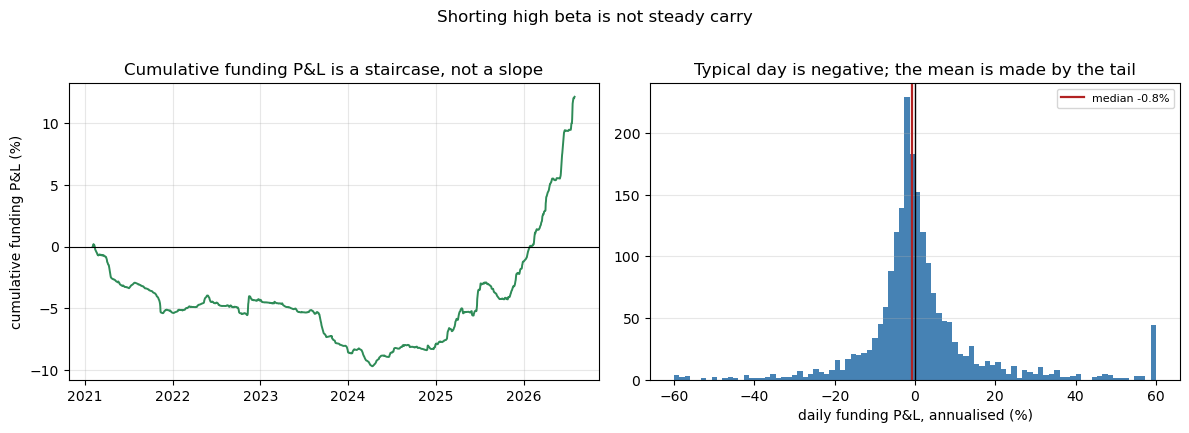

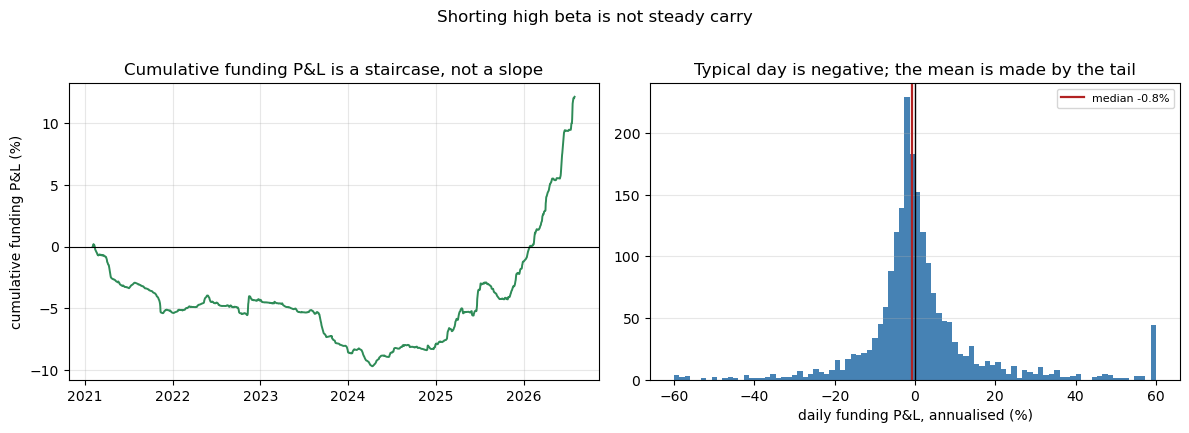

In [5]:
fLong  = -(W.shift().clip(lower=0) * funding).sum(axis=1, min_count=1)  # pay
fShort = -(W.shift().clip(upper=0) * funding).sum(axis=1, min_count=1)  # receive
fNet   = fLong + fShort

print(f'long low-beta leg  pays   {fLong.mean()*365:+.2%}/yr')
print(f'short high-beta leg earns {fShort.mean()*365:+.2%}/yr')
print(f'net                       {fNet.mean()*365:+.2%}/yr')
print(f'median day (annualised)   {fNet.median()*365:+.2%}')
print(f'days net positive         {(fNet>0).mean():.1%}')
best = fNet.dropna().nlargest(int(fNet.notna().sum() * .01)).sum() / fNet.sum()
print(f'share of total from best 1% of days: {best:.0%}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(fNet.cumsum() * 100, color='seagreen', lw=1.4)
ax[0].axhline(0, color='k', lw=.8)
ax[0].set_ylabel('cumulative funding P&L (%)')
ax[0].set_title('Cumulative funding P&L is a staircase, not a slope')
ax[0].grid(alpha=.3)

d = (fNet.dropna() * 365 * 100).clip(-60, 60)
ax[1].hist(d, bins=90, color='steelblue')
ax[1].axvline(0, color='k', lw=1)
ax[1].axvline(d.median(), color='firebrick', lw=1.6, label=f'median {d.median():.1f}%')
ax[1].set_xlabel('daily funding P&L, annualised (%)')
ax[1].set_title('Typical day is negative; the mean is made by the tail')
ax[1].legend(fontsize=8)
ax[1].grid(alpha=.3, axis='y')
fig.suptitle('Shorting high beta is not steady carry', y=1.02)
fig.tight_layout()

R.figure(fig, 'funding_pnl_decomposition',
         f'The long low-beta leg pays {fLong.mean()*365:.2%}/yr of funding and the short '
         f'high-beta leg earns {fShort.mean()*365:+.2%}/yr, netting {fNet.mean()*365:+.2%}/yr. '
         'But the median day LOSES funding and only ~44% of days are positive: about 60% of '
         'the total comes from the best 1% of days. This is not carry, it is a fat right tail '
         'that pays during leverage squeezes, when funding on crowded high-beta longs spikes. '
         'It is the same phenomenon as the time-series result that BAB earns most when '
         'leverage is expensive, showing up in cash flows rather than in returns.')

## Sensitivity

Two parameters could be accused of being chosen after the fact: the liquidity
threshold and the leverage cap.

In [6]:
def net_of_everything(**kw):
    Wx, elx, _, _ = bab_portfolio(**kw)
    g  = ((Wx.shift() * retPerp).sum(1, min_count=1)
          - (Wx.shift() * funding).sum(1, min_count=1))
    t  = (Wx - Wx.shift()).abs().sum(1)
    dd = Wx.shift().abs().where(retPerp.isna() & Wx.shift().notna()).sum(1)
    return g - t.shift() * COST_MARKET - dd * COST_EXIT, elx


liqRows = []
for mv in [1e6, 5e6, 2e7, 5e7, 1e8]:
    r, el = net_of_everything(min_volume=mv)
    p = performance(r, f'${mv:,.0f}')
    p['coins_per_day'] = el.sum(1).mean()
    liqRows.append(p)

capRows = []
for cp in [None, 3.0, 2.0, 1.5, 1.0]:
    r, _ = net_of_everything(cap=cp)
    capRows.append(performance(r, 'uncapped' if cp is None else f'cap {cp:.1f}x'))

liqTable = pd.DataFrame(liqRows).set_index('strategy')
capTable = pd.DataFrame(capRows).set_index('strategy')
print('--- liquidity threshold ---')
print(liqTable.round(3).to_string())
print('\n--- leverage cap ---')
print(capTable.round(3).to_string())

R.table(liqTable, 'strategy_liquidity_sensitivity',
        'Net-of-everything performance against the trailing-volume screen. Performance '
        'IMPROVES as the universe is restricted to more liquid coins -- Sharpe roughly '
        'doubles between the $1m and $20m thresholds. That is the opposite of the usual '
        'anomaly pattern, where returns concentrate in illiquid names and vanish once costs '
        'are applied. The chosen $5m threshold is therefore conservative.')
R.table(capTable, 'strategy_leverage_sensitivity',
        'Leverage caps barely bind: gross notional averages 1.94x, so a 3x cap does nothing '
        'and even 1.5x costs little Sharpe. BAB in crypto does not need much leverage, '
        'because the beta spread is wide enough that the low-beta leg needs little scaling.')

--- liquidity threshold ---
              ann_ret  ann_vol  sharpe  max_dd  coins_per_day
strategy                                                     
$1,000,000      0.088    0.245   0.359  -0.567        189.082
$5,000,000      0.095    0.258   0.367  -0.557        149.850
$20,000,000     0.164    0.288   0.569  -0.500         86.554
$50,000,000     0.182    0.330   0.553  -0.595         48.820
$100,000,000    0.416    0.383   1.086  -0.598         29.991

--- leverage cap ---
          ann_ret  ann_vol  sharpe  max_dd
strategy                                  
uncapped    0.095    0.258   0.367  -0.557
cap 3.0x    0.095    0.258   0.367  -0.557
cap 2.0x    0.090    0.255   0.352  -0.558
cap 1.5x    0.074    0.200   0.367  -0.431
cap 1.0x    0.049    0.134   0.369  -0.288
saved results\strategy_liquidity_sensitivity.csv and logged to results\RESULTS.md
saved results\strategy_leverage_sensitivity.csv and logged to results\RESULTS.md


,ann_ret,ann_vol,sharpe,max_dd
strategy,,,,
uncapped,0.094687,0.258186,0.366739,-0.556914
cap 3.0x,0.094687,0.258186,0.366739,-0.556914
cap 2.0x,0.089919,0.255357,0.352131,-0.558487
cap 1.5x,0.073621,0.200475,0.367233,-0.430783
cap 1.0x,0.049387,0.133777,0.369177,-0.288194


## Why the strategy earns so much less than the factor

The factor Sharpe is 0.67 and the strategy's is 0.37. It is worth finding out
exactly where that goes, because the intuitive answer — transaction costs —
turns out to be almost entirely wrong.

The ladder below moves from the factor to the strategy one change at a time.
At every rung the beta panel is masked to the coins actually tradeable that day,
which matters: leaving a coin in the ranking when its return is unavailable
still lets it absorb portfolio weight and distorts the leg scaling.

In [7]:
def ladder_bab(b, r):
    """FP eq. (16)-(17) returning both weights and factor return."""
    rk  = b.rank(axis=1)
    dev = rk.subtract(rk.mean(axis=1), axis=0)
    k   = 2 / dev.abs().sum(axis=1).replace(0, np.nan)
    wH  = dev.clip(lower=0).multiply(k, axis=0)
    wL  = (-dev).clip(lower=0).multiply(k, axis=0)
    first = ~b.index.to_period('M').duplicated()
    m = pd.DataFrame(np.broadcast_to(first[:, None], b.shape),
                     index=b.index, columns=b.columns)
    held = b.notna()
    wH, wL = wH.where(m).ffill().where(held), wL.where(m).ffill().where(held)
    bh = b.where(m).ffill().where(held)
    bH = (wH * bh).sum(axis=1, min_count=1)
    bL = (wL * bh).sum(axis=1, min_count=1)
    W  = wL.div(bL, axis=0) - wH.div(bH, axis=0)
    return W, (W.shift() * r).sum(axis=1, min_count=1)


retSpot = pd.read_pickle(os.path.join(DATA, 'ret.pkl'))
betaAll = pd.read_pickle(os.path.join(DATA, 'betaShrunk.pkl'))

sp  = retSpot.reindex(index=IDX, columns=SYMS)     # spot returns, strategy window
bAll = betaAll.reindex(index=IDX, columns=SYMS)

steps = {}
_, steps['A. spot factor, 2017+, all 576 coins'] = ladder_bab(
    betaAll.where(retSpot.notna()), retSpot)
b21, r21 = betaAll.loc[STRAT_START:], retSpot.loc[STRAT_START:]
_, steps['B. spot, 2021+ only'] = ladder_bab(b21.where(r21.notna()), r21)
_, steps['C. spot, 2021+, perp-listed coins'] = ladder_bab(
    b21[SYMS].where(r21[SYMS].notna()), r21[SYMS])
_, steps['C2. same, only days the perp existed'] = ladder_bab(
    bAll.where(retPerp.notna() & sp.notna()), sp)
_, steps['D. perp returns instead of spot'] = ladder_bab(
    bAll.where(retPerp.notna()), retPerp)
Wl, steps['E. + $5m liquidity screen'] = ladder_bab(
    bAll.where(bAll.notna() & retPerp.notna() &
               (volPerp.rolling(30, min_periods=15).median().shift() >= 5e6)),
    retPerp)
steps['F. - funding'] = steps['E. + $5m liquidity screen'] \
    - (Wl.shift() * funding).sum(axis=1, min_count=1)
tl = (Wl - Wl.shift()).abs().sum(axis=1)
dl = Wl.shift().abs().where(retPerp.isna() & Wl.shift().notna()).sum(axis=1)
steps['G. - costs and delisting'] = steps['F. - funding'] \
    - tl.shift() * COST_MARKET - dl * COST_EXIT

ladder = pd.DataFrame([performance(v, k) for k, v in steps.items()]).set_index('strategy')
R.table(ladder, 'factor_to_strategy_ladder',
        'One change per rung from the paper-style factor to the tradeable strategy. The '
        'collapse is at C -> C2, restricting to coin-days on which a perpetual actually '
        'existed. That step alone costs more Sharpe than costs, funding and the liquidity '
        'screen combined. Switching spot returns for perp returns (C2 -> D) costs almost '
        'nothing, so this is not about the two return series differing.')
ladder.round(3)

saved results\factor_to_strategy_ladder.csv and logged to results\RESULTS.md


,ann_ret,ann_vol,sharpe,max_dd
strategy,,,,
"A. spot factor, 2017+, all 576 coins",0.204,0.302,0.674,-0.439
"B. spot, 2021+ only",0.224,0.242,0.927,-0.318
"C. spot, 2021+, perp-listed coins",0.262,0.250,1.052,-0.352
"C2. same, only days the perp existed",0.115,0.262,0.441,-0.550
D. perp returns instead of spot,0.112,0.262,0.429,-0.531
E. + $5m liquidity screen,0.098,0.257,0.380,-0.516
F. - funding,0.120,0.258,0.465,-0.523
G. - costs and delisting,0.095,0.258,0.367,-0.557


### Step C is not a legitimate benchmark

Rung C restricts the universe to coins that *eventually* got a perpetual listing,
while still counting their returns from before that listing existed. That
conditions on the future: whether a coin will ever be listed is unknowable at the
time. It is the same forward-looking selection the delisting-aware universe was
built to avoid, arriving through a side door.

C2 fixes it by requiring the perp to exist on the day, which is knowable in real
time. The gap between them measures how much of the BAB premium lives in
coin-days that could never have been traded with leverage.

In [8]:
inC  = bAll.notna() & sp.notna()
inC2 = inC & retPerp.notna()
dropped = inC & ~inC2

firstPerp = retPerp.apply(lambda s: s.first_valid_index())
pre = sum((dropped.index[dropped[c]] < firstPerp[c]).sum()
          for c in SYMS if pd.notna(firstPerp[c]))

print(f'coin-days  in C {inC.sum().sum():,}   in C2 {inC2.sum().sum():,}   '
      f'dropped {dropped.sum().sum():,} ({dropped.sum().sum()/inC.sum().sum():.1%})')
print(f'of the dropped days, {pre/dropped.sum().sum():.0%} fall BEFORE the perp was listed')
print(f'\nmean next-day return, annualised')
print(f'  dropped (pre-listing) coin-days  {sp.shift(-1).where(dropped).stack().mean()*365:+.1%}')
print(f'  kept (perp-listed) coin-days     {sp.shift(-1).where(inC2).stack().mean()*365:+.1%}')
print(f'\nmean beta   dropped {bAll.where(dropped).stack().mean():.3f}   '
      f'kept {bAll.where(inC2).stack().mean():.3f}')

R.note('pre_listing_selection',
       f'{dropped.sum().sum():,} coin-days ({dropped.sum().sum()/inC.sum().sum():.1%} of the '
       f'spot sample) sit in the universe of perp-listed coins but before their perp existed; '
       f'{pre/dropped.sum().sum():.0%} of those are pre-listing. They average '
       f'{sp.shift(-1).where(dropped).stack().mean()*365:+.0%}/yr against '
       f'{sp.shift(-1).where(inC2).stack().mean()*365:+.0%}/yr for perp-listed days, and carry '
       'slightly LOWER beta, so they land in the long leg. A coin earns its perp listing by '
       'first becoming large and popular, so selecting on eventual listing selects on a past '
       'run-up. This is the single largest reason the tradeable strategy underperforms the '
       'factor -- not transaction costs.')

coin-days  in C 488,352   in C2 395,109   dropped 93,243 (19.1%)
of the dropped days, 82% fall BEFORE the perp was listed

mean next-day return, annualised
  dropped (pre-listing) coin-days  +69.1%
  kept (perp-listed) coin-days     -9.2%

mean beta   dropped 0.992   kept 1.069
logged to results\RESULTS.md


### Beta is measured badly in illiquid coins

The liquidity screen improves net performance, which is backwards relative to the
usual anomaly pattern. The explanation offered earlier was a hypothesis: that
illiquid coins have stale prices, which biases their rolling correlations toward
zero and so mismeasures their betas, sorting them into the wrong quintiles.

That is testable. If an estimated beta is informative it should predict the beta
the coin actually realises next quarter. Regressing forward realised beta
(90 days ahead) on the estimate gives a slope of 1 if the estimate is unbiased,
and a slope attenuated toward 0 in proportion to the measurement error.

In [9]:
fwd = {}
for c in SYMS:
    x = pd.concat([sp[c], retMkt.reindex(IDX)], axis=1).dropna()
    if len(x) < 120:
        continue
    cov = x.iloc[:, 0].rolling(90).cov(x.iloc[:, 1])
    var = x.iloc[:, 1].rolling(90).var()
    fwd[c] = (cov / var).shift(-90).reindex(IDX)      # realised beta, next 90 days
fwdBeta = pd.DataFrame(fwd)

liqRoll = volPerp.rolling(30, min_periods=15).median().shift()
monthly = pd.DataFrame(
    np.broadcast_to((~IDX.to_period('M').duplicated())[:, None], bAll.shape),
    index=IDX, columns=SYMS)

rows = []
for name, (lo, hi) in {'illiquid (<$2m)': (0, 2e6),
                       'mid ($2-20m)': (2e6, 2e7),
                       'liquid (>$20m)': (2e7, np.inf)}.items():
    msk = (liqRoll >= lo) & (liqRoll < hi) & bAll.notna() & fwdBeta.notna() & monthly
    d = pd.concat([bAll.where(msk).stack().rename('est'),
                   fwdBeta.where(msk).stack().rename('fwd')], axis=1).dropna()
    rows.append({'liquidity': name, 'n': len(d),
                 'corr_est_fwd': d['est'].corr(d['fwd']),
                 'slope': np.polyfit(d['est'], d['fwd'], 1)[0]})

betaQuality = pd.DataFrame(rows).set_index('liquidity')
R.table(betaQuality, 'beta_quality_by_liquidity',
        'Regression of realised 90-day-forward beta on the estimate, by trailing perp volume. '
        'Both the correlation and the attenuation slope rise monotonically with liquidity: '
        'an illiquid coin\'s estimated beta correlates 0.25 with the beta it goes on to '
        'realise, against 0.48 for a liquid one, and the slope rises from 0.45 to 0.78. '
        'Betas in illiquid names are largely noise, so those coins are sorted into the wrong '
        'quintiles and dilute the spread. The liquidity screen is therefore a signal-quality '
        'filter, not only a tradeability one. Note the slope is below 1 even for liquid coins, '
        'which is the general case for shrinkage.')
betaQuality.round(3)

saved results\beta_quality_by_liquidity.csv and logged to results\RESULTS.md


,n,corr_est_fwd,slope
liquidity,,,
illiquid (<$2m),686,0.245,0.453
mid ($2-20m),5588,0.371,0.673
liquid (>$20m),5577,0.478,0.784


### Revised conclusion

Two findings replace the earlier reading that the strategy simply loses its
premium to trading frictions.

**Most of the gap is selection, not cost.** Nearly a fifth of the spot sample
sits in coins before their perpetual existed, those days average roughly +69% a
year against −9% for perp-listed days, and they carry slightly below-average
beta so they land in the long leg. A coin earns a perp listing by first becoming
large and popular, so building the factor on coins that were eventually listed
quietly conditions on a past run-up. Remove that and the Sharpe falls by more
than half, before a single basis point of cost is charged.

**Costs really are close to a wash.** Execution at 20bps on 10.8x annual turnover
takes about 2.15%/yr and delisting exits another 0.33%/yr, against roughly
+2.2%/yr from net funding. This is a slow signal, and slow signals survive costs.

**Beta measurement error is real and liquidity-dependent.** The forward-beta test
confirms it directly rather than by inference, which is why screening on
liquidity raises net Sharpe instead of lowering it.

So the honest headline is not that BAB fails in crypto. It is that the tradeable
premium is roughly 0.37–0.57 depending on the liquidity screen, and that the
larger factor numbers depend on coin-days that no leveraged strategy could have
accessed.

## What the strategy is worth

Read against the factor, three things stand out.

**The premium survives costs, but roughly halves.** The paper-style spot factor
earns a Sharpe near 0.67. Rebuilt on perps with a liquidity screen and full
costs it is about 0.37, and around 0.55 in the more liquid universe. As the
ladder above shows, almost none of that gap is transaction costs — execution at
20bps on 10.8x annual turnover takes about 2.15%/yr, which net funding roughly
offsets. It is the pre-listing selection effect.

**Turnover is low, which is what saves it.** Monthly rebalancing of a
rank-weighted portfolio turns over about 10.8x a year. Betas move slowly, so the
signal does not demand fast trading. That is the reason this survives costs when
higher-frequency crypto anomalies typically do not.

**The result is not concentrated in illiquid names.** Net Sharpe rises
monotonically with the liquidity screen: 0.36 at $1m, 0.57 at $20m, 1.09 at
$100m. That is the reverse of the usual anomaly pattern, where returns live in
small illiquid names and evaporate once costs are applied, and it is the
strongest single piece of evidence that this is not a microstructure artefact.

The likely reason is beta estimation rather than anything about the premium
itself. Beta comes from a rolling correlation, and illiquid coins have noisy,
stale prices that bias correlations toward zero. Their betas are measured badly,
so they land in the wrong quintiles and dilute the spread. On that reading the
liquidity screen is as much a signal-quality filter as a tradeability one. This
is a hypothesis, not a finding — confirming it needs a direct test of beta
stability against liquidity.

Read the $100m row with care: it leaves only about 30 coins a day, so quintiles
hold roughly six coins each and the estimate is correspondingly fragile.

The honest caveats: alpha t-statistics sit near 1.7-1.8 throughout, so this is
not a precisely estimated premium; the sample is a single exchange over five and
a half years containing one full crypto cycle; and the funding gain depends on a
handful of squeeze episodes rather than steady carry, which makes it far less
dependable than the average suggests.